In [15]:
import os
import pandas as pd
import numpy as np
import datetime
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import itertools
from scipy.stats import skew
import statsmodels.api as sm
import scipy.stats
from scipy.optimize import differential_evolution
from multiprocessing import Pool
import scipy.special
import numba
from concurrent.futures import ProcessPoolExecutor, as_completed
from netCDF4 import Dataset
import glob
import matplotlib.pyplot as plt
import calendar
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from convertbng.util import convert_bng, convert_lonlat

In [16]:
## Data/time series preparation stage begins from here ##
def prepare_point_timeseries(df, season_definitions, completeness_threshold, durations, outlier_method,
        maximum_relative_difference, maximum_alterations):
    """
    Prepare point timeseries for analysis.

    Steps are: (1) subset on reference calculation period, (2) define seasons for grouping, (3) applying any trimming
    or clipping to reduce the influence of outliers, and (4) aggregating timeseries to required durations.

    """
    # Check valid or nan  # TODO: Revisit if this function gets used for non-precipitation variables
    df.loc[df['value'] < 0.0] = np.nan

    # Apply season definitions and make a running UID for season that goes up by one at each change in season
    # through the time series. Season definitions are needed to identify season completeness but also to apply
    # trimming or clipping
    df['season'] = df.index.month.map(season_definitions)
    df['season_uid'] = df['season'].ne(df['season'].shift()).cumsum()

    # Mask periods not meeting data completeness threshold (close approximation). There is an assumption of at
    # least one complete version of each season in dataframe (where complete means that nans may be present - i.e.
    # fine unless only a very short (< 1 year) record is passed in)
    if df['value'].isnull().any():
        df['season_count'] = df.groupby('season_uid')['value'].transform('count')
        df['season_size'] = df.groupby('season_uid')['value'].transform('size')
        df['season_size'] = df.groupby('season')['season_size'].transform('median')
        df['completeness'] = df['season_count'] / df['season_size'] * 100.0
        df['completeness'] = np.where(df['completeness'] > 100.0, 100.0, df['completeness'])
        df.loc[df['completeness'] < completeness_threshold, 'value'] = np.nan
        df = df.loc[:, ['season', 'value']]

    # Apply trimming or clipping season-wise
    if outlier_method == 'trim':
        df['value'] = df.groupby('season')['value'].transform(
            trim_array(maximum_relative_difference, maximum_alterations)
        )
    elif outlier_method == 'clip':
        df['value'] = df.groupby('season')['value'].transform(
            clip_array(maximum_relative_difference, maximum_alterations)
        )

    # Find timestep and convert from datetime to period index if needed
    if not isinstance(df.index, pd.PeriodIndex):
        datetime_difference = df.index[1] - df.index[0]
    else:
        datetime_difference = df.index[1].to_timestamp() - df.index[0].to_timestamp()
    timestep_length = int(datetime_difference.days * 24) + int(datetime_difference.seconds / 3600)  # hours
    period = str(timestep_length) + 'H'  # TODO: Sort out sub-hourly timestep
    if not isinstance(df.index, pd.PeriodIndex):
        df = df.to_period(period)

    duration_hours = []
    for duration in durations:
        duration_units = duration[-1]
        if duration_units == 'H':
            duration_hours.append(int(duration[:-1]))
        elif duration_units == 'D':
            duration_hours.append(int(duration[:-1]) * 24)
        elif duration_units == 'M':
            duration_hours.append(31 * 24)
    duration_hours = np.asarray(duration_hours)
    sorted_durations = np.asarray(durations)[np.argsort(duration_hours)]

    # Aggregate timeseries to required durations
    dfs = {}
    for duration in sorted_durations:
        # resample_code = str(int(duration)) + 'H'  # TODO: Check/add sub-hourly
        resample_code = duration
        duration_units = duration[-1]
        if duration_units == 'H':
            duration_hours = int(duration[:-1])
        elif duration_units == 'D':
            duration_hours = int(duration[:-1]) * 24
        elif duration_units == 'M':
            duration_hours = 31 * 24

        # Final day needed for a given aggregation
        # - relies on multiples of one day if duration exceeds 24 hours
        # - constrained to monthly
        # - maximum duration of 28 days(?)
        if duration_hours > 24:
            duration_days = int(duration_hours / 24)

            # Interim aggregation to daily to see if it speeds things up
            if '24H' in durations:
                df1 = dfs['24H'].copy()
            elif '1D' in durations:
                df1 = dfs['1D'].copy()

            n_groups = int(np.ceil(31 / duration_days))
            df1['group'] = -1
            for group in range(n_groups):
                if duration_units != 'M':
                    df1['group'] = np.where(df1.index.day >= group * duration_days + 1, group, df1['group'])
                else:
                    # df1['month'] = df1.index.month
                    # df1['group'] = df1['month'].ne(df1['month'].shift()).cumsum()
                    # df1.drop(columns=['month'], inplace=True)
                    df1['group'] = 0

            # df1 = df.groupby([df.index.year, df.index.month, 'group'])['value'].agg(['sum', 'count'])
            df1 = df1.groupby([df1.index.year, df1.index.month, 'group'])['value'].agg(['sum', 'count'])
            if df1.index.names[0] == 'datetime':  # !221025 - for dfs coming from shuffling (fitting delta)
                df1.index.rename(['level_0', 'level_1', 'group'], inplace=True)
            df1.reset_index(inplace=True)
            df1['day'] = df1['group'] * duration_days + 1
            df1.rename(columns={'level_0': 'year', 'level_1': 'month'}, inplace=True)
            df1['datetime'] = pd.to_datetime(df1[['year', 'month', 'day']])
            df1.drop(columns=['year', 'month', 'day', 'group'], inplace=True)
            df1.set_index('datetime', inplace=True)
            # print(df1)
        else:
            df1 = df['value'].resample(resample_code, closed='left', label='left').agg(['sum', 'count'])
            # df2 = df['value'].resample(resample_code, closed='left', label='left').count()

        # df1 = df['value'].resample(resample_code, closed='left', label='left').sum()
        # df2 = df['value'].resample(resample_code, closed='left', label='left').count()

        # Remove data below a duration-dependent completeness
        if duration_hours <= 24:  # TODO: Remove hardcoding of timestep requiring complete data and completeness threshold?
            expected_count = int(duration_hours / timestep_length)
        else:
            expected_count = ((duration_hours / timestep_length) / 24) * 0.9  # TODO: Remove hardcoding - user option
        # df1.values[df2.values < expected_count] = np.nan  # duration
        df1.rename(columns={'sum': 'value'}, inplace=True)
        df1.loc[df1['count'] < expected_count, 'value'] = np.nan
        df1.drop(columns=['count'], inplace=True)
        df1.sort_index(inplace=True)
        df1['season'] = df1.index.month.map(season_definitions)
        dfs[duration] = df1
        dfs[duration] = dfs[duration][dfs[duration]['value'].notnull()]
        
    return dfs


def trim_array(max_relative_difference, max_removals):
    def f(x):
        y = x.copy()
        removals = 0
        while True:
            y_max = np.max(y)
            y_max_count = np.sum(y == y_max)
            y_next_largest = np.max(y[y < y_max])
            if y_max / y_next_largest > max_relative_difference:
                if removals + y_max_count <= max_removals:
                    y = y[y < y_max]
                    removals += y_max_count
                else:
                    break
            else:
                break
        return y  # , removals
    return f


def clip_array(max_relative_difference, max_clips):
    # - assuming working with zero-bounded values
    def f(x):
        y = x.copy()
        clips = 0
        clip_flag = -999
        while True:
            y_max = np.max(y)
            y_max_count = np.sum(y == y_max)
            y_next_largest = np.max(y[y < y_max])
            if y_max / y_next_largest > max_relative_difference:
                if clips + y_max_count <= max_clips:
                    y[y == y_max] = clip_flag
                    clips += y_max_count
                else:
                    break
            else:
                break
        y[y == clip_flag] = np.max(y)
        return y  # , clips
    return f


## We get reference statistics from this stage and 
## data preparation stage ends here 

def GetMonthStats(ListofDFs,WET_THRESHOLD):
    '''
    This function requires outputs from the functions PrepareTimeSeriesPoint
    and nested_dictionary_to_dataframe
    '''
    dc = {
            1: {'weight': 1.0, 'duration': '1H', 'name': 'variance'},
            2: {'weight': 2.0, 'duration': '1H', 'name': 'skewness'},
            3: {'weight': 7.0, 'duration': '1H', 'name': f'probability_dry_{WET_THRESHOLD}mm', 'threshold': WET_THRESHOLD},
            4: {'weight': 6.0, 'duration': '24H', 'name': 'mean'},
            5: {'weight': 2.0, 'duration': '24H', 'name': 'variance'},
            6: {'weight': 3.0, 'duration': '24H', 'name': 'skewness'},
            7: {'weight': 7.0, 'duration': '24H', 'name': f'probability_dry_{WET_THRESHOLD}mm', 'threshold': WET_THRESHOLD},
            8: {'weight': 6.0, 'duration': '24H', 'name': 'autocorrelation_lag1', 'lag': 1},
            9: {'weight': 3.0, 'duration': '72H', 'name': 'variance'},
            10: {'weight': 0.0, 'duration': '1M', 'name': 'variance'},
        }
    id_name = 'statistic_id'
    non_id_columns = ['name', 'duration', 'lag', 'threshold', 'weight']


    def nested_dictionary_to_dataframe(dc, id_name, non_id_columns):
        ids = sorted(list(dc.keys()))
        data = {}
        for non_id_column in non_id_columns:
            data[non_id_column] = []
            for id_ in ids:
                values = dc[id_]
                data[non_id_column].append(
                    values[non_id_column] if non_id_column in values.keys() else 'NA'
                )
        dc1 = {}
        dc1[id_name] = ids
        for non_id_column in non_id_columns:
            dc1[non_id_column] = data[non_id_column]
        df = pd.DataFrame(dc1)
        return df
        
    statistic_definitions = nested_dictionary_to_dataframe(dc, id_name, non_id_columns)
    statistic_definitions = statistic_definitions[statistic_definitions['duration']!='1H'].reset_index(drop = True)
    
    statistic_definitions[statistic_definitions['duration']=='24H'].name
    statistic_definitions[statistic_definitions['duration']=='72H'].name
    statistic_definitions[statistic_definitions['duration']=='1M'].name

    ListofDFs['24H']['Month'] = [ListofDFs['24H'].index[i].month for i in np.arange(0,ListofDFs['24H'].shape[0],1)]
    ListofDFs['24H']['Year'] = [ListofDFs['24H'].index[i].year for i in np.arange(0,ListofDFs['24H'].shape[0],1)]

    ListofDFs['72H']['Month'] = [ListofDFs['72H'].index[i].month for i in np.arange(0,ListofDFs['72H'].shape[0],1)]
    ListofDFs['72H']['Year'] = [ListofDFs['72H'].index[i].year for i in np.arange(0,ListofDFs['72H'].shape[0],1)]

    ListofDFs['1M']['Month'] = [ListofDFs['1M'].index[i].month for i in np.arange(0,ListofDFs['1M'].shape[0],1)]
    ListofDFs['1M']['Year'] = [ListofDFs['1M'].index[i].year for i in np.arange(0,ListofDFs['1M'].shape[0],1)]

    MEAN_24H = [np.nanmean(ListofDFs['24H']['value'][ListofDFs['24H']['Month']==i]) for i in range(1,13)]
    VAR_24H = [np.nanvar(ListofDFs['24H']['value'][ListofDFs['24H']['Month']==i]) for i in range(1,13)]
    SKEW_24H = [skew(ListofDFs['24H']['value'][ListofDFs['24H']['Month'] == i]) for i in range(1, 13)]
    PROB_24H = [len(ListofDFs['24H']['value'][(ListofDFs['24H']['Month'] == i) & (ListofDFs['24H']['value'] < WET_THRESHOLD)].values)/len(ListofDFs['24H']['value'][ListofDFs['24H']['Month']==i]) for i in range(1,13)]

    def getacf(MONTHNUM):
        df=pd.DataFrame({'x': ListofDFs['24H']['value'][ListofDFs['24H']['Month']==MONTHNUM], 'x_lag': ListofDFs['24H']['value'][ListofDFs['24H']['Month']==MONTHNUM].shift(1)})
        df.dropna(inplace=True)
        acf,pval = scipy.stats.pearsonr(df['x'], df['x_lag'])
        return acf
 
    ACF_24H=[getacf(i) for i in range(1,13)]
    VAR_72H = [np.nanvar(ListofDFs['72H']['value'][ListofDFs['72H']['Month']==i]) for i in range(1,13)]
    VAR_1M = [np.nanvar(ListofDFs['1M']['value'][ListofDFs['1M']['Month']==i]) for i in range(1,13)]

    # standardization of the statistics
    STAN_MEAN_24H = np.mean([np.nanmean(ListofDFs['24H']['value'][ListofDFs['24H']['Year']==i]) for i in np.arange(min(ListofDFs['24H']['Year']),max(ListofDFs['24H']['Year'])+1,1)])
    STAN_VAR_24H = np.mean([np.nanvar(ListofDFs['24H']['value'][ListofDFs['24H']['Year']==i]) for i in np.unique(ListofDFs['24H']['Year'])])
    STAN_SKEW_24H = np.mean([skew(ListofDFs['24H']['value'][ListofDFs['24H']['Year']==i], nan_policy='omit') for i in np.unique(ListofDFs['24H']['Year'])])
    STAN_VAR_72H = np.mean([np.nanvar(ListofDFs['72H']['value'][ListofDFs['72H']['Year']==i]) for i in np.unique(ListofDFs['72H']['Year'])])
    STAN_VAR_1M = np.mean([np.nanvar(ListofDFs['1M']['value'][ListofDFs['1M']['Year']==i]) for i in np.unique(ListofDFs['1M']['Year'])])

    STAT =  pd.DataFrame({'statistic_id':np.repeat(range(1,statistic_definitions.shape[0]+1),12),
       'name':np.repeat(statistic_definitions['name'],12),
       'duration':np.repeat(statistic_definitions['duration'],12),
       'month':np.tile(range(1,13),statistic_definitions.shape[0]),
       'value':np.concatenate((MEAN_24H,VAR_24H,SKEW_24H,PROB_24H,ACF_24H,VAR_72H,VAR_1M)),
       'weight':np.repeat(statistic_definitions['weight'],12),
       'gs':np.concatenate((np.repeat(STAN_MEAN_24H,12),np.repeat(STAN_VAR_24H,12),np.repeat(STAN_SKEW_24H,12),np.repeat(1,24),np.repeat(STAN_VAR_72H,12),np.repeat(STAN_VAR_1M,12))),
       'phi':np.repeat(1,12*statistic_definitions.shape[0])})
    
    STAT.loc[STAT['name'].str.contains('lag1'), 'lag'] = 1
    STAT.loc[STAT['name'].str.contains('probability_dry'), 'threshold'] = WET_THRESHOLD
    return STAT
    

In [17]:
##  Getting reference statistics stage ends here and 
##  fitting stage begins from here 

def prepare(statistics):
    statistic_ids = sorted(list(set(statistics['statistic_id'])))

    fitting_data = {}
    reference_statistics = []
    weights = []
    gs = []
    for statistic_id in statistic_ids:
        df = statistics.loc[statistics['statistic_id'] == statistic_id].copy()

        fitting_data[(statistic_id, 'name')] = df['name'].values[0]
        fitting_data[(statistic_id, 'duration')] = df['duration'].values[0]
        fitting_data[(statistic_id, 'lag')] = df['lag'].values[0]
        fitting_data[(statistic_id, 'threshold')] = df['threshold'].values[0]
        fitting_data[(statistic_id, 'df')] = df

        reference_statistics.append(df['value'].values)
        weights.append(df['weight'].values)
        gs.append(df['gs'].values)

    reference_statistics = np.concatenate(reference_statistics)
    weights = np.concatenate(weights)
    gs = np.concatenate(gs)

    return statistic_ids, fitting_data, reference_statistics, weights, gs


def fitting_wrapper_point(
        parameters, intensity_distribution, statistic_ids, fitting_data,
        ref_stats, weights, gs, all_parameter_names, parameters_to_fit,
        fixed_parameters, month
):
    """
    Objective function for monthly point NSRP fitting.
    Compares modelled statistics to observed statistics for one month.
    """
    # Build full parameter dictionary
    parameters_dict = {}
    for pname in all_parameter_names:
        if pname in parameters_to_fit:
            parameters_dict[pname] = parameters[parameters_to_fit.index(pname)]
        else:
            parameters_dict[pname] = fixed_parameters[(month, pname)]

    # Calculate model statistics
    mod_stats = calculate_analytical_properties(
        spatial_model=False,
        intensity_distribution=intensity_distribution,
        parameters_dict=parameters_dict,
        statistic_ids=statistic_ids,
        fitting_data=fitting_data
    )

    # Return weighted and scaled error
    return calculate_objective_function(ref_stats, mod_stats, weights, gs)

def fit_by_month_point(
        unique_months, reference_statistics, intensity_distribution,
        all_parameter_names, parameters_to_fit, parameter_bounds,
        fixed_parameters, n_workers=1, stage='final', initial_parameters=None
):
    """
    Fit NSRP parameters for each month independently (point model only).
    """
    results = {}
    fitted_statistics = []

    for month in unique_months:
        # Filter reference statistics for current month
        month_ref_stats = reference_statistics.loc[reference_statistics['month'] == month].copy()

        # Prepare fitting data
        statistic_ids, fitting_data, ref, weights, gs = prepare(month_ref_stats)

        # Parameter bounds for this month
        bounds = [parameter_bounds[(month, p)] for p in parameters_to_fit]

        # Initial guess if available
        x0 = initial_parameters[month] if initial_parameters is not None else None

        # Run optimisation
        result = differential_evolution(
            func=fitting_wrapper_point,
            bounds=bounds,
            args=(intensity_distribution, statistic_ids, fitting_data, ref,
                  weights, gs, all_parameter_names, parameters_to_fit,
                  fixed_parameters, month),
            tol=0.001,
            updating='deferred',
            workers=n_workers,
            x0=x0
        )

        # Store results for this month
        for idx, pname in enumerate(parameters_to_fit):
            results[(pname, month)] = result.x[idx]
        results[('converged', month)] = result.success
        results[('objective_function', month)] = result.fun
        results[('iterations', month)] = result.nit
        results[('function_evaluations', month)] = result.nfev

        # Build parameter dictionary for fitted stats
        parameters_dict = {}
        for pname in all_parameter_names:
            if pname in parameters_to_fit:
                parameters_dict[pname] = results[(pname, month)]
            else:
                parameters_dict[pname] = fixed_parameters[(month, pname)]

        # Calculate fitted statistics
        mod_stats = calculate_analytical_properties(
            spatial_model=False,
            intensity_distribution=intensity_distribution,
            parameters_dict=parameters_dict,
            statistic_ids=statistic_ids,
            fitting_data=fitting_data
        )

        df_stats = month_ref_stats.copy()
        df_stats['value'] = mod_stats
        df_stats['month'] = month
        fitted_statistics.append(df_stats)

    # Format parameter table
    parameters_df = format_results(results, all_parameter_names, parameters_to_fit, fixed_parameters, unique_months,intensity_distribution)
    parameters_df['fit_stage'] = stage

    # Combine fitted statistics
    fitted_statistics = pd.concat(fitted_statistics)
    fitted_statistics['fit_stage'] = stage

    return parameters_df, fitted_statistics

def calculate_analytical_properties(spatial_model, intensity_distribution, parameters_dict, statistic_ids, fitting_data):
    
    # Unpack parameter values common to point and spatial models
    lamda = parameters_dict['lamda']
    beta = parameters_dict['beta']
    eta = parameters_dict['eta']
    theta = parameters_dict['theta']

    # Get or calculate nu
    if not spatial_model:
        nu = parameters_dict['nu']
    else:
        rho = parameters_dict['rho']
        gamma = parameters_dict['gamma']
        nu = 2.0 * np.pi * rho / gamma ** 2.0

    # Shape parameters are only relevant to non-exponential intensity distributions
    if intensity_distribution == 'weibull':
        kappa = parameters_dict['kappa']
    elif intensity_distribution == 'generalised_gamma':
        kappa_1 = parameters_dict['kappa_1']
        kappa_2 = parameters_dict['kappa_2']

    # Calculate raw moments (1-3) of intensity distribution
    moments = []
    for n in [1, 2, 3]:
        if intensity_distribution == 'exponential':
            moments.append(scipy.stats.expon.moment(n, scale=theta))
        elif intensity_distribution == 'weibull':
            moments.append(scipy.stats.weibull_min.moment(n, c=kappa, scale=theta))
        elif intensity_distribution == 'generalised_gamma':
            moments.append(scipy.stats.gengamma.moment(n, a=(kappa_1 / kappa_2), c=kappa_2, scale=theta))
    mu_1, mu_2, mu_3 = moments

    # Duration string → numeric hours mapping
    duration_map = {
        '1h': 1.0,
        '24h': 24.0,
        '72h': 72.0,
        '1m': 24.0 * 30.0  # approx 30 days per month, adjust if needed
    }

    statistic_arrays = []
    for statistic_id in statistic_ids:
        name = fitting_data[(statistic_id, 'name')]
        duration_str = fitting_data[(statistic_id, 'duration')]
        # normalize strings to lower-case to match robustly
        name_l = str(name).lower()
        dur_l = str(duration_str).lower()

        # convert duration to numeric hours
        if dur_l in duration_map:
            duration_val = duration_map[dur_l]
        else:
            # try to parse numeric prefix if user used formats like '1H' or '24H' etc.
            try:
                if dur_l.endswith('h'):
                    duration_val = float(dur_l[:-1])
                elif dur_l.endswith('m') and len(dur_l) > 1:  # '1M' treat as month
                    duration_val = duration_map.get('1m', 24.0 * 30.0)
                else:
                    duration_val = float(dur_l)
            except Exception:
                raise ValueError(f"Unknown duration string: {duration_str}")

        phi = np.ones(len(fitting_data[(statistic_id, 'df')]))

        # detect statistic types using substring matching
        is_autocorr = 'autocorrelation' in name_l
        is_crosscorr = 'cross-correlation' in name_l or 'cross_correlation' in name_l or 'cross correlation' in name_l or 'cross' in name_l and 'correlation' in name_l
        is_prob = 'probability_dry' in name_l or name_l.startswith('probability')
        is_mean = 'mean' in name_l and not is_prob
        is_variance = 'variance' in name_l
        is_skew = 'skew' in name_l

        if is_autocorr or is_crosscorr:
            lag = fitting_data[(statistic_id, 'lag')]
            if is_crosscorr:
                phi2 = np.ones(len(fitting_data[(statistic_id, 'df')]))
                distances = fitting_data[(statistic_id, 'df')].get('distance', pd.Series([])).values
        elif is_prob:
            threshold = fitting_data[(statistic_id, 'threshold')]

        # compute appropriate statistic
        if is_mean:
            values = calculate_mean(duration_val, lamda, nu, mu_1, eta, phi)
        elif is_variance:
            values = calculate_variance(duration_val, eta, beta, lamda, nu, mu_1, mu_2, phi)
        elif is_skew:
            values = calculate_skewness(duration_val, eta, beta, lamda, nu, mu_1, mu_2, mu_3, phi)
        elif is_autocorr:
            values = calculate_autocorrelation(duration_val, lag, eta, beta, lamda, nu, mu_1, mu_2, phi)
        elif is_prob:
            # call probability dry with threshold if available (may be NaN)
            values = calculate_probability_dry(duration_val, nu, beta, eta, lamda, phi, threshold if 'threshold' in locals() else None)
        elif is_crosscorr:
            values = calculate_cross_correlation(duration_val, lag, eta, beta, lamda, nu, mu_1, mu_2, gamma, distances, phi, phi2)
        else:
            # if nothing matches, raise to avoid silent mis-assignment
            raise ValueError(f"Unknown statistic name: {name} (normalized: {name_l})")

        statistic_arrays.append(np.atleast_1d(values))

    return np.concatenate(statistic_arrays)

def calculate_objective_function(ref, mod, w, sf):
   obj_fun = np.sum((w ** 2 / sf ** 2) * (ref - mod) ** 2)
   return obj_fun


def _mean(h, lamda, nu, mu_X, eta, phi=1):
    """
    Mean of NSRP process.Equation 2.11 in Cowpertwait (1995), which is Equation 5 in Cowpertwait et al. (2002).
    """
    mean_ = phi * h * lamda * nu * mu_X / eta
    return mean_


def calculate_mean(duration, lamda, nu, mu_1, eta, phi):
    mean_ = _mean(duration, lamda, nu, mu_1, eta, phi)
    return mean_


def _covariance_a_b_terms(h, l, eta, beta, lamda, nu, mu_X):
    """A and B terms needed in covariance calculations.

    See Equations 2.12, 2.15 and 2.16 in Cowpertwait (1995).

    """
    # Cowpertwait (1995) equations 2.15 and 2.16
    if l == 0:
        A_hl = 2 * (h * eta + np.exp(-eta * h) - 1) / eta ** 2
        B_hl = 2 * (h * beta + np.exp(-beta * h) - 1) / beta ** 2
    else:
        A_hl = (1 - np.exp(-eta * h)) ** 2 * np.exp(-eta * h * (l - 1)) / eta ** 2
        B_hl = (1 - np.exp(-beta * h)) ** 2 * np.exp(-beta * h * (l - 1)) / beta ** 2

    # Cowpertwait (1995) equation 2.12
    Aij = 0.5 * lamda * beta * nu ** 2 * mu_X ** 2 * ((2 * beta) / ((beta ** 2 - eta ** 2) * (2 * eta)))
    Bij = -0.5 * lamda * beta * nu ** 2 * mu_X ** 2 * (1 / ((beta - eta) * (beta + eta)))

    return A_hl, B_hl, Aij, Bij

def _site_covariance(h, l, eta, beta, lamda, nu, mu_X, var_X, phi=1):
    """Covariance of NSRP process.

    Covariance is calculated as Equation 2.14 in Cowpertwait (1995). This
    requires A and B terms from calculate_A_and_B().

    """
    A_hl, B_hl, Aij, Bij = _covariance_a_b_terms(h, l, eta, beta, lamda, nu, mu_X)

    # Cowpertwait (1995) equation 2.14
    cov = (
            phi ** 2 * (A_hl * Aij + B_hl * Bij) + phi ** 2 * lamda * nu * var_X * A_hl / eta
    )
    return cov

def calculate_variance(duration, eta, beta, lamda, nu, mu_1, mu_2, phi):
    variance = _site_covariance(duration, 0, eta, beta, lamda, nu, mu_1, mu_2, phi)
    return variance



def _skewness_f(eta, beta, h):
    """f-function needed for calculating third central moment.

    Equation 2.10 in Cowpertwait (1998), which is Equation 11 in Cowpertwait
    et al. (2002).

    """
    f = (
        # line 1
        -2 * eta ** 3 * beta ** 2 * np.exp(-eta * h) - 2 * eta ** 3 * beta ** 2 * np.exp(-beta * h)
        + eta ** 2 * beta ** 3 * np.exp(-2 * eta * h) + 2 * eta ** 4 * beta * np.exp(-eta * h)
        # line 2
        + 2 * eta ** 4 * beta * np.exp(-beta * h) + 2 * eta ** 3 * beta ** 2 * np.exp(-(eta + beta) * h)
        - 2 * eta ** 4 * beta * np.exp(-(eta + beta) * h) - 8 * eta ** 3 * beta ** 3 * h
        # line 3
        + 11 * eta ** 2 * beta ** 3 - 2 * eta ** 4 * beta + 2 * eta ** 3 * beta ** 2
        + 4 * eta * beta ** 5 * h + 4 * eta ** 5 * beta * h - 7 * beta ** 5
        # line 4
        - 4 * eta ** 5 + 8 * beta ** 5 * np.exp(-eta * h) - beta ** 5 * np.exp(-2 * eta * h)
        - 2 * h * eta ** 3 * beta ** 3 * np.exp(-eta * h)
        # line 5
        - 12 * eta ** 2 * beta ** 3 * np.exp(-eta * h) + 2 * h * eta * beta ** 5 * np.exp(-eta * h)
        + 4 * eta ** 5 * np.exp(-beta * h)
    )
    return f


def _skewness_g(eta, beta, h):
    """f-function needed for calculating third central moment.

    Equation 2.11 in Cowpertwait (1998), which is Equation 12 in Cowpertwait
    et al. (2002).

    """
    g = (
        # line 1
        12 * eta ** 5 * beta * np.exp(-beta * h) + 9 * eta ** 4 * beta ** 2 + 12 * eta * beta ** 5 * np.exp(-eta * h)
        + 9 * eta ** 2 * beta ** 4
        # line 2
        + 12 * eta ** 3 * beta ** 3 * np.exp(-(eta + beta) * h) - eta ** 2 * beta ** 4 * np.exp(-2 * eta * h)
        - 12 * eta ** 3 * beta ** 3 * np.exp(-beta * h) - 9 * eta ** 5 * beta
        # line 3
        - 9 * eta * beta ** 5 - 3 * eta * beta ** 5 * np.exp(-2 * eta * h)
        - eta ** 4 * beta ** 2 * np.exp(-2 * beta * h) - 12 * eta ** 3 * beta ** 3 * np.exp(-eta * h)
        # line 4
        + 6 * eta ** 5 * beta ** 2 * h - 10 * beta ** 4 * eta ** 3 * h + 6 * beta ** 5 * eta ** 2 * h
        - 10 * beta ** 3 * eta ** 4 * h + 4 * beta ** 6 * eta * h
        # line 5
        - 8 * beta ** 2 * eta ** 4 * np.exp(-beta * h) + 4 * beta * eta ** 6 * h + 12 * beta ** 3 * eta ** 3
        - 8 * beta ** 4 * eta ** 2 * np.exp(-eta * h) - 6 * eta ** 6
        # line 6
        - 6 * beta ** 6 - 2 * eta ** 6 * np.exp(-2 * beta * h) - 2 * beta ** 6 * np.exp(-2 * eta * h)
        + 8 * eta ** 6 * np.exp(-beta * h)
        # line 7
        + 8 * beta ** 6 * np.exp(-eta * h) - 3 * beta * eta ** 5 * np.exp(-2 * beta * h)
    )
    return g


def _third_central_moment(
        h, eta, beta, lamda, nu, mu_X, var_X, X_mom3
):
    """Third central moment of NSRP process.

    Equation 2.9 in Cowpertwait (1998), which is Equation 10 in Cowpertwait
    et al. (2002). Requires f-function and g-function from skewness_f() and
    skewness_g(), respectively.

    """
    f = _skewness_f(eta, beta, h)
    g = _skewness_g(eta, beta, h)

    # Cowpertwait (1998) equation 2.9
    skew = (
        # line 1
        6 * lamda * nu * X_mom3 * (eta * h - 2 + eta * h * np.exp(-eta * h) + 2 * np.exp(-eta * h)) / eta ** 4
        # line 2
        + 3 * lamda * mu_X * var_X * nu ** 2 * f
        # line 3
        / (2 * eta ** 4 * beta * (beta ** 2 - eta ** 2) ** 2) + lamda * mu_X ** 3
        # line 4
        * nu ** 3 * g
        # line 5
        / (2 * eta ** 4 * beta * (eta ** 2 - beta ** 2) * (eta - beta) * (2 * beta + eta) * (beta + 2 * eta))
    )
    return skew



def calculate_skewness(duration, eta, beta, lamda, nu, mu_1, mu_2, mu_3, phi):
    unscaled_variance = _site_covariance(duration, 0, eta, beta, lamda, nu, mu_1, mu_2, phi * 0.0 + 1.0)
    third_moment = _third_central_moment(duration, eta, beta, lamda, nu, mu_1, mu_2, mu_3)
    skewness = third_moment / (unscaled_variance ** 0.5) ** 3
    return skewness


def calculate_autocorrelation(duration, lag, eta, beta, lamda, nu, mu_1, mu_2, phi):
    variance = _site_covariance(duration, 0, eta, beta, lamda, nu, mu_1, mu_2, phi)
    lag_covariance = _site_covariance(duration, lag, eta, beta, lamda, nu, mu_1, mu_2, phi)
    autocorrelation = lag_covariance / variance
    return autocorrelation


def _omega(beta, t, eta):
    """Omega term in Equation 2.17 in Cowpertwait (1995).

    Probability that a cell overlapping point m with arrival time in (0, t)
    terminates before t. Same as Equation 2.15 in Cowpertwait (1994).

    """
    omega = 1 - beta * (np.exp(-beta * t) - np.exp(-eta * t)) / ((eta - beta) * (1 - np.exp(-beta * t)))
    return omega

def _probability_zero_t_0(t, nu, beta, eta):
    """Probability of no rain in (0, t).

    Equation 2.18 in Cowpertwait (1995) but setting t=0 and h=t.

    Returns 1 minus the probability, as this is what is needed to find the dry
    probability using Equation 2.19 in Cowpertwait (1995).

    """
    omega_ = _omega(beta, t, eta)
    p = np.exp(-nu + nu * np.exp(-beta * (0 + t)) + omega_ * nu * (1 - np.exp(-beta * 0)))
    return 1 - p



def _probability_zero_h_t(t, h, nu, beta, eta):
    """Probability of no rain in (t, t+h) due to a storm origin at time zero.

    Equation 2.18 in Cowpertwait (1995). I.e. differs from Cowpertwait (1994),
    as number of cells per storm is a Poisson random variable, whereas
    Cowpertwait (1994) used a geometric distribution.

    Returns 1 minus the probability, as this is what is needed to find the dry
    probability using Equation 2.19 in Cowpertwait (1995).

    """
    omega_ = _omega(beta, t, eta)

    # Cowpertwait (1995) equation 2.18
    p = np.exp(-nu + nu * np.exp(-beta * (t + h)) + omega_ * nu * (1 - np.exp(-beta * t)))
    return 1 - p

def _probability_dry(h, nu, beta, eta, lamda):
    """Probability dry (equal to zero) for NSRP process.

    Equation 2.19 in Cowpertwait (1995).

    """
    term1, term1_error = scipy.integrate.quad(_probability_zero_h_t, 0, np.inf, args=(h, nu, beta, eta))
    term2, term2_error = scipy.integrate.quad(_probability_zero_t_0, 0, h, args=(nu, beta, eta))
    p = np.exp(-lamda * term1 - lamda * term2)
    return p


def _probability_dry_correction(h, threshold, uncorr_pdry):
    """Estimation of dry probability for non-zero thresholds.

    Following Section 4.3 in Burton et al. (2008). Options are only for 24hr
    duration (thresholds of 0.2 or 1.0 mm).
    """
    if h == 24:
        if threshold == 1.0:
                corr_pdry = 0.14883306000969174 + 0.9159842728203157 * uncorr_pdry 
        elif threshold == 0.2:
            corr_pdry = 0.0812432886563782 + 0.9750231398157361 * uncorr_pdry 

    # elif h == 1:

    #     # Burton et al. (2008) equation 10
    #     if threshold == 0.1:
    #         corr_pdry = 0.114703 + 0.884491 * uncorr_pdry

    #     # Burton et al. (2008) equation 11
    #     elif threshold == 0.2:
    #         corr_pdry = 0.239678 + 0.758837 * uncorr_pdry
        corr_pdry = max(corr_pdry, 0.0)
        corr_pdry = min(corr_pdry, 1.0)

    return corr_pdry


def calculate_probability_dry(duration, nu, beta, eta, lamda, phi, threshold=0.2):
    probability_dry = _probability_dry(duration, nu, beta, eta, lamda)
    #if threshold is not None:
        #probability_dry = _probability_dry_correction(duration, threshold, probability_dry)
    probability_dry = phi * 0.0 + probability_dry
    probability_dry = np.clip(probability_dry, 0.0, 1.0)
    return probability_dry



def _probability_overlap_integral_expression(y, gamma, d):
    # Cowpertwait et al. (2002) equation 8 / Cowpertwait (2010) page 3
    expr = ((gamma * d) / (2 * np.cos(y)) + 1) * np.exp((-gamma * d) / (2 * np.cos(y)))
    return expr


def _cross_covariance(h, l, eta, beta, lamda, nu, mu_X, var_X, gamma, d, phi1=1, phi2=1):
    # Cell overlap probability
    integral_term, error = scipy.integrate.quad(
        _probability_overlap_integral_expression, 0, np.pi / 2, args=(gamma, d)
    )
    overlap_probability = 2 / np.pi * integral_term

    a_hl, b_hl, aij, bij = _covariance_a_b_terms(h, l, eta, beta, lamda, nu, mu_X)

    # Cowpertwait (1995) equation 2.24
    cov = (
            phi1 * phi2 * (a_hl * aij + b_hl * bij)
            + phi1 * phi2 * lamda * overlap_probability * nu * var_X * a_hl / eta
    )

    return cov


def calculate_cross_correlation(
        duration, lag, eta, beta, lamda, nu, mu_1, mu_2, gamma, distances, phi1, phi2
):
    # For lags > 0 then need to calculate unscaled_variance for both lag=0 and lag=lag
    # then use these appropriately below - IMPLEMENT THIS
    if lag != 0:
        raise ValueError('Cross-correlation not yet implemented for lags > 0')
    else:
        pass

    cross_correlations = []

    unscaled_variance = _site_covariance(duration, lag, eta, beta, lamda, nu, mu_1, mu_2, 1)

    for idx in range(phi1.shape[0]):
        variance1 = unscaled_variance * phi1[idx] ** 2
        variance2 = unscaled_variance * phi2[idx] ** 2
        covariance = _cross_covariance(duration, lag, eta, beta, lamda, nu, mu_1, mu_2, gamma, distances[idx], phi1[idx],phi2[idx])  # h, l, eta, beta, lamda, nu, mu_X, var_X, gamma, d, phi1=1, phi2=1
        cross_correlation = covariance / (variance1 ** 0.5 * variance2 ** 0.5)
        cross_correlations.append(cross_correlation)

    return np.asarray(cross_correlations)


def format_results(results, all_parameter_names, parameters_to_fit, fixed_parameters, unique_months, intensity_distribution):
    """
    Format fitted results into a consistent dataframe for NSRP point model.

    Args:
        results (dict): Optimisation results dictionary.
        all_parameter_names (list): All possible parameter names.
        parameters_to_fit (list): Parameters being fitted.
        fixed_parameters (dict): Dictionary of fixed parameters {(month,param): value}.
        unique_months (list): List of months (1-12).
        intensity_distribution (str): 'exponential', 'weibull', or 'generalised_gamma'.

    Returns:
        pd.DataFrame: Formatted dataframe with consistent column order.
    """
    dc = results.copy()

    # Insert fixed parameters if missing
    for param in all_parameter_names:
        if param not in parameters_to_fit:
            for m in unique_months:
                dc[(param, m)] = fixed_parameters.get((m, param), np.nan)

    # Convert dict -> dataframe
    df = pd.DataFrame.from_dict(dc, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['field', 'month'])
    df.reset_index(inplace=True)
    df = df.pivot(index='month', columns='field', values='value')
    df.sort_index(inplace=True)
    df.reset_index(inplace=True)

    # Cast types
    type_map = {
        'month': int,
        'converged': bool,
        'iterations': int,
        'function_evaluations': int,
        'objective_function': float
    }
    for col, t in type_map.items():
        if col in df.columns:
            df[col] = df[col].astype(t)

    # Define desired order depending on distribution
    if intensity_distribution == 'exponential':
        desired_order = ['fit_stage','month','lamda','beta','nu','eta','theta',
                         'converged','objective_function','iterations','function_evaluations']
    elif intensity_distribution == 'weibull':
        desired_order = ['fit_stage','month','lamda','beta','nu','eta','theta','kappa',
                         'converged','objective_function','iterations','function_evaluations']
    elif intensity_distribution == 'generalised_gamma':
        desired_order = ['fit_stage','month','lamda','beta','nu','eta','theta','kappa_1','kappa_2',
                         'converged','objective_function','iterations','function_evaluations']
    else:
        raise ValueError(f"Unknown distribution: {intensity_distribution}")

    # Reorder, keeping only existing columns
    df = df.reindex(columns=[c for c in desired_order if c in df.columns])

    return df


In [18]:
## Stage-4: Fitting stage ends here and NSRP simulation stage begins ##
#############################################
# The steps in simulation of the NSRP process are:  
#     1. Simulate storms as a temporal Poisson process.
#     2. Simulate raincells.
#     3. Simulate raincell arrival times.
#     4. Simulate raincell durations.
#     5. Simulate raincell intensities.

def simulate_storms(month_lengths, simulation_length, parameters, rng):
    simulation_end_time = np.cumsum(month_lengths)[-1]

    sim_len_ext = simulation_length + 4
    month_lengths_ext = month_lengths.copy()
    for _ in range(4):
        month_lengths_ext = np.concatenate([month_lengths_ext, month_lengths[-12:]])

    lamda = np.tile(parameters['lamda'].values, sim_len_ext)
    cumulative_expected_storms = np.cumsum(lamda * month_lengths_ext)
    cumulative_month_endtimes = np.cumsum(month_lengths_ext)
    expected_number_of_storms = cumulative_expected_storms[-1]
    number_of_storms = rng.poisson(expected_number_of_storms)

    deformed_arrivals = expected_number_of_storms * np.sort(rng.uniform(size=number_of_storms))
    cumulative_expected_storms = np.insert(cumulative_expected_storms, 0, 0.0)
    cumulative_month_endtimes = np.insert(cumulative_month_endtimes, 0, 0.0)
    interpolator = scipy.interpolate.interp1d(
        cumulative_expected_storms, cumulative_month_endtimes
    )
    storm_arrival_times = interpolator(deformed_arrivals)

    storm_arrival_times = storm_arrival_times[storm_arrival_times < simulation_end_time]
    number_of_storms = storm_arrival_times.shape[0]
    storms = pd.DataFrame({
        'storm_id': np.arange(number_of_storms),
        'storm_arrival': storm_arrival_times
    })
    storms['month'] = lookup_months(month_lengths, simulation_length, storms['storm_arrival'].values)
    return storms, number_of_storms


def lookup_months(month_lengths, period_length, times):
    end_times = np.cumsum(month_lengths)
    repeated_months = np.tile(np.arange(1, 13, dtype=int), period_length)
    idx = np.digitize(times, end_times)
    return repeated_months[idx]


def simulate_raincells_point(storms, parameters, rng):
    tmp = pd.merge(storms, parameters, how='left', on='month')
    tmp.sort_values(['storm_id'], inplace=True)

    number_of_raincells = rng.poisson(tmp['nu'].values)
    storm_ids, storm_arrivals, storm_months = make_storm_arrays_by_raincell(
        number_of_raincells,
        storms['storm_id'].values,
        storms['storm_arrival'].values,
        storms['month'].values
    )
    return pd.DataFrame({
        'storm_id': storm_ids,
        'storm_arrival': storm_arrivals,
        'month': storm_months
    })


def make_storm_arrays_by_raincell(num_cells, storm_ids, storm_arrivals, storm_months):
    return (
        np.repeat(storm_ids, num_cells),
        np.repeat(storm_arrivals, num_cells),
        np.repeat(storm_months, num_cells)
    )


def merge_parameters(df, month_lengths, simulation_length, parameters):
    df['month'] = lookup_months(month_lengths, simulation_length, df['storm_arrival'].values)
    parameters_subset = parameters.drop(
        ['fit_stage', 'converged', 'objective_function',
         'iterations', 'function_evaluations'],
        axis=1, errors='ignore'
    )
    return pd.merge(df, parameters_subset, how='left', on='month')


def main_point_model_monthly(parameters,simulation_length,month_lengths,intensity_distribution,rng):
    """
    NSRP point model simulation (monthly parameters).

    Args:
        parameters (pandas.DataFrame): Parameters dataframe from fitting (must include 'month', 'lamda', 'beta', 'nu', 'eta', 'theta', etc.).
        simulation_length (int): Number of years to simulate.
        month_lengths (numpy.ndarray): Hours in each month to be simulated.
        intensity_distribution (str): Raincell intensity distribution ('exponential', 'weibull', 'generalised_gamma').
        rng (numpy.random.Generator): Random number generator.

    Steps:
        1. Simulate storms (temporal Poisson process).
        2. Simulate raincells for each storm.
        3. Simulate raincell arrival times.
        4. Simulate raincell durations.
        5. Simulate raincell intensities.
    """

    # Ensure dataframe is sorted by month
    parameters = parameters.copy()
    parameters.sort_values(by='month', inplace=True)

    # Step 1 - Simulate storms
    storms, number_of_storms = simulate_storms(month_lengths, simulation_length, parameters, rng)

    # Step 2 - Simulate raincells
    df = simulate_raincells_point(storms, parameters, rng)

    # Merge parameters into master dataframe
    df = pd.merge(df, parameters, how='left', on='month')

    # Step 3 - Raincell arrival times
    raincell_arrival_times = rng.exponential(1.0 / df['beta'])  # relative to storm origin
    df['raincell_arrival'] = df['storm_arrival'] + raincell_arrival_times

    # Step 4 - Raincell durations
    df['raincell_duration'] = rng.exponential(1.0 / df['eta'])
    df['raincell_end'] = df['raincell_arrival'] + df['raincell_duration']

    # Step 5 - Raincell intensities
    if intensity_distribution == 'exponential':
        df['raincell_intensity'] = rng.exponential(df['theta'])
    elif intensity_distribution == 'weibull':
        df['raincell_intensity'] = scipy.stats.weibull_min.rvs(
            c=df['kappa'], scale=df['theta'], random_state=rng
        )
    elif intensity_distribution == 'generalised_gamma':
        df['raincell_intensity'] = scipy.stats.gengamma.rvs(
            a=(df['kappa_1'] / df['kappa_2']), c=df['kappa_2'],
            scale=df['theta'], random_state=rng
        )

    # Clean up parameters from output (optional)
    df.drop(columns=['lamda', 'beta', 'rho', 'eta', 'gamma', 'theta', 'kappa'],
            inplace=True, errors='ignore')

    return df


def initialise_discrete_rainfall_arrays_point(n_timesteps):
    """
    Create zero-filled array for point rainfall output.

    Args:
        n_timesteps (int): Total number of timesteps in the simulation.

    Returns:
        dict: {'point': np.ndarray of shape (n_timesteps, 1)}
    """
    return {'point': np.zeros((n_timesteps, 1))}



def discretise_point(period_start_time, timestep_length,raincell_arrival_times, raincell_end_times,
                     raincell_intensities, discrete_rainfall):
    """
    Convert raincells into discrete timestep rainfall totals.

    Args:
        period_start_time (float): Simulation start time in hours.
        timestep_length (float): Length of each timestep in hours.
        raincell_arrival_times (np.ndarray): Raincell start times in hours.
        raincell_end_times (np.ndarray): Raincell end times in hours.
        raincell_intensities (np.ndarray): Raincell intensities (mm/hr).
        discrete_rainfall (np.ndarray): Array to store output (modified in place).
    """
    discrete_rainfall.fill(0.0)  # Reset to zero before filling

    for idx in range(raincell_arrival_times.shape[0]):
        # Times relative to simulation/block start
        rc_arrival_time = raincell_arrival_times[idx] - period_start_time
        rc_end_time = raincell_end_times[idx] - period_start_time
        rc_intensity = raincell_intensities[idx]

        # Timesteps covered
        rc_arrival_timestep = int(np.floor(rc_arrival_time / timestep_length))
        rc_end_timestep = int(np.floor(rc_end_time / timestep_length))

        # Distribute intensity across affected timesteps
        for timestep in range(rc_arrival_timestep, rc_end_timestep + 1):
            timestep_start_time = timestep * timestep_length
            timestep_end_time = (timestep + 1) * timestep_length
            effective_start = max(rc_arrival_time, timestep_start_time)
            effective_end = min(rc_end_time, timestep_end_time)
            timestep_coverage = effective_end - effective_start

            if timestep < discrete_rainfall.shape[0] and timestep_coverage > 0:
                discrete_rainfall[timestep, 0] += rc_intensity * timestep_coverage


def get_storm_depths_point(df):
    """
    Summarise storm total depth and duration from raincell dataframe.

    Args:
        df (pd.DataFrame): NSRP raincell output with columns:
            ['storm_id', 'storm_arrival', 'month', 'raincell_duration', 'raincell_intensity', 'raincell_end']

    Returns:
        pd.DataFrame: Storm-level statistics.
    """
    df['raincell_depth'] = df['raincell_duration'] * df['raincell_intensity']

    storm_stats = df.groupby(['storm_id']).agg({
        'storm_arrival': 'min',
        'month': 'min',
        'raincell_depth': 'sum',
        'raincell_end': 'max'
    }).reset_index()

    storm_stats.rename(columns={'raincell_depth': 'storm_depth',
                                'raincell_end': 'storm_end'}, inplace=True)
    storm_stats['storm_duration'] = storm_stats['storm_end'] - storm_stats['storm_arrival']
    storm_stats.drop(columns=['storm_end'], inplace=True)

    return storm_stats


def discretise_by_point_monthly(df_raincells, simulation_length_years, InputTimeSeries, timestep_length=24.0):
    # Input: timestep_length in hours (default 24 -> produce daily totals)
    Start = pd.to_datetime(str(int(InputTimeSeries.index.year[0])) + '-01-01')
    End = pd.to_datetime(str(int(InputTimeSeries.index.year[0]) + simulation_length_years - 1) + '-12-31')
    DatesVect = pd.date_range(start=Start, end=End, freq="D")
    monthly_df = pd.DataFrame({'Year': DatesVect.year, 'Month': DatesVect.month})
    HRCOUNT = monthly_df.groupby(['Year', 'Month']).size().reset_index(name='n_days')
    month_days = HRCOUNT['n_days'].to_numpy()

    # number of timesteps per month given timestep_length (hours)
    timesteps_per_month = (month_days * 24 / timestep_length).astype(int)  # usually days if timestep_length==24
    total_timesteps = timesteps_per_month.sum()

    # Create discrete output at the requested timestep resolution
    discrete_rainfall = np.zeros((total_timesteps, 1))

    # Loop months and use hours-based start/end for mask
    start_ts = 0
    start_hour = 0.0
    for m_idx, days_in_month in enumerate(month_days):
        hours_in_month = days_in_month * 24.0
        end_hour = start_hour + hours_in_month
        end_ts = start_ts + timesteps_per_month[m_idx]

        # mask must compare hours to hours
        mask = ((df_raincells['raincell_arrival'] < end_hour) & (df_raincells['raincell_end'] > start_hour))
        raincells_month = df_raincells.loc[mask]

        # slice the output array corresponding to this month (timesteps, 1)
        discretise_point(
            period_start_time=start_hour,
            timestep_length=timestep_length,
            raincell_arrival_times=raincells_month['raincell_arrival'].values,
            raincell_end_times=raincells_month['raincell_end'].values,
            raincell_intensities=raincells_month['raincell_intensity'].values,
            discrete_rainfall=discrete_rainfall[start_ts:end_ts]
        )

        # advance
        start_hour = end_hour
        start_ts = end_ts

    return discrete_rainfall


def initialise_hourly_array(total_hours):
    # One column for point model, all zeros initially
    return np.zeros((total_hours, 1), dtype=float)

##This marks the end of functions relevant to NSRP simulation stage. 


In [19]:
### Now we have completed time series preparation, reference statistics
### computation, parameter fitting and NSRP simulation phases for the rainfall data.
### Following this we shall load data on other weather variables to  
### kickstart the weather generator. The first step in this process is to
### prepare the weather time series - preprocessing and transformation, and the functions begin from here.


def prepare_weather_series(input_timeseries,input_variables,calculation_period,
    completeness_threshold,wet_threshold,season_length,point_id=1):
    
    # Read data
    #df = pd.read_csv(input_timeseries, index_col=0, parse_dates=True, infer_datetime_format=True)
    df = input_timeseries
    df.columns = [column.lower() for column in df.columns]

    # Assign month or half-month identifiers
    if season_length == 'half-month':
        df['season'] = identify_half_months(df.index)
    elif season_length == 'month':
        df['season'] = df.index.month

    # Subset on calculation period
    if calculation_period is not None:
        df = df.loc[(df.index.year >= calculation_period[0]) & (df.index.year <= calculation_period[1])]
    
    period_length = (datetime.datetime(calculation_period[1], 12, 31) - datetime.datetime(calculation_period[0], 1, 1))
    period_length = period_length.days + 1
    
    # Check enough data to continue
    if df.shape[0] >= 365:
        # Add wet day indicator
        df['wet_day'] = np.where(np.isfinite(df['prcp']) & (df['prcp'] >= wet_threshold), 1, 0)
        df['wet_day'] = np.where(~np.isfinite(df['prcp']), np.nan, df['wet_day'])

        # Compute derived temperature variables if present
        if 'temp_min' in df.columns and 'temp_max' in df.columns:
            df['temp_avg'] = (df['temp_min'] + df['temp_max']) / 2.0
            df['dtr'] = df['temp_max'] - df['temp_min']

        # Identify completeness by variable
        completeness = {}
        for variable in input_variables:
            if variable in df.columns:
                if df.shape[0] > 0:
                    if (variable in ['temp_avg', 'dtr']) and ('prcp' in df.columns):
                        completeness[variable] = (
                            np.sum(np.isfinite(df['prcp']) & np.isfinite(df[variable])) / period_length * 100
                        )
                    elif ('prcp' in df.columns) and ('temp_avg' in df.columns):
                        completeness[variable] = (
                            np.sum(
                                np.isfinite(df['prcp']) &
                                np.isfinite(df['temp_avg']) &
                                np.isfinite(df[variable])
                            ) / period_length * 100
                        )
                    else:
                        completeness[variable] = 0.0
                    completeness[variable] = min(completeness[variable], 100.0)
                    if completeness[variable] < completeness_threshold:
                        df.drop(columns=[variable], inplace=True)
                else:
                    completeness[variable] = 0.0
            else:
                completeness[variable] = 0.0

        # Need at least one variable to be sufficiently complete
        if max(completeness.values()) >= completeness_threshold:
            if 'datetime' not in df.columns:
                df.reset_index(inplace=True)

            # Reshape to long format
            df = pd.melt(df, id_vars=['datetime', 'season', 'prcp', 'wet_day'])

            # Filter relevant variables
            df = df.loc[~df['variable'].isin(['temp_mean', 'temp_min', 'temp_max', 'rel_hum'])]

            # Transition states
            df['wet_day_lag1'] = df['wet_day'].shift(1)
            df['wet_day_lag2'] = df['wet_day'].shift(2)
            df['transition'] = 'NA'
            df['transition'] = np.where((df['wet_day_lag1'] == 1) & (df['wet_day'] == 1), 'WW', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 0) & (df['wet_day'] == 1), 'DW', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 1) & (df['wet_day'] == 0), 'WD', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 0) & (df['wet_day'] == 0), 'DD', df['transition'])
            df['transition'] = np.where(
                (df['wet_day_lag2'] == 0) & (df['wet_day_lag1'] == 0) & (df['wet_day'] == 0), 'DDD', df['transition']
            )
            df.drop(columns=['wet_day', 'wet_day_lag1', 'wet_day_lag2'], inplace=True)

            # Move precipitation into variable form
            tmp1 = df.loc[
                df['variable'] == df['variable'].unique()[0], ['datetime', 'season', 'transition', 'prcp']
            ].copy()
            tmp1.rename(columns={'prcp': 'value'}, inplace=True)
            tmp1['variable'] = 'prcp'
            df.drop(columns=['prcp'], inplace=True)
            df = pd.concat([df, tmp1])

            # Compute seasonal stats and z-scores
            df1 = df.loc[df['transition'] != 'NA']
            df1 = df1.groupby(['variable', 'season'])['value'].agg(['mean', 'std']).reset_index()
            df = pd.merge(df, df1, on=['variable', 'season'])
            df['z_score'] = (df['value'] - df['mean']) / df['std']
            df.drop(columns=['mean', 'std'], inplace=True)

            # Add point ID
            df['point_id'] = point_id
            df1['point_id'] = point_id

        else:
            df, completeness, df1 = None, None, None

    else:
        df, completeness, df1 = None, None, None

    return df, df1, completeness


def identify_half_months(date_series):
    half_months = np.zeros(date_series.shape[0], dtype=int)
    current_half_month = 1
    for month in range(1, 13):
        half_months[(date_series.month == month) & (date_series.day <= 15)] = current_half_month
        current_half_month += 1
        half_months[(date_series.month == month) & (date_series.day > 15)] = current_half_month
        current_half_month += 1
    return half_months


def transform_series(InputWeatherSeries,base_seed):
    
    df = InputWeatherSeries[0]
    df = df.rename(columns={'point_id': 'pool_id'})
    # Factors by which to stratify transformation
    #transitions = ['DDD', 'DD', 'DW', 'WD', 'WW', 'NA']  # ! is NA needed to keep serially complete here?
    variables = df['variable'].unique()
    pool_ids = df['pool_id'].unique()
    seasons = df['season'].unique()
    transformations = {}
    offsetlist = {}
    # Main loop
    dfs = []
    # for season, transition, variable, pool_id in itertools.product(self.seasons, transitions, variables, pool_ids):  # !221212
    for season, variable, pool_id in itertools.product(seasons, variables, pool_ids):  # !221212
        df1 = df.loc[
            (df['season'] == season) & (df['variable'] == variable)  # (df['transition'] == transition) &  # !221212
            & (df['pool_id'] == pool_id) & (np.isfinite(df['z_score']))
        ].copy()
        
        if (df1.shape[0] > 0) and (variable in ['temp_avg', 'dtr']):
            offset = abs(df1['z_score'].min()) + 0.01 
            bc_value, lamda = scipy.stats.boxcox(df1['z_score'] + offset)
            df1['bc_value'] = bc_value
            dfs.append(df1)
            transformations[(pool_id, variable, season, 'lamda')] = lamda
            offsetlist[(pool_id, variable, season, 'offset')] = offset

        elif (df1.shape[0] > 0) and (variable == 'sun_dur'):
            # TODO: Keep track of min/max used in scaling? Or assume min=0 and max=fully sunny day?
            # Alternatively could calculate day length here and use this - may be the most accurate

            p0 = df1.loc[df1['value'] < 0.01, 'value'].shape[0] / df1.shape[0]
            df1['scaled'] = (df1['value'] - df1['value'].min()) / (df1['value'].max() - df1['value'].min())

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                a, b, loc, scale = scipy.stats.beta.fit(df1.loc[df1['value'] >= 0.01, 'scaled'])
            transformations[(pool_id, variable, season, 'p0')] = p0
            transformations[(pool_id, variable, season, 'a')] = a
            transformations[(pool_id, variable, season, 'b')] = b
            transformations[(pool_id, variable, season, 'loc')] = loc
            transformations[(pool_id, variable, season, 'scale')] = scale

            # Recording min/max of observations for now, but see above
            transformations[(pool_id, variable, season, 'obs_min')] = df1['value'].min()
            transformations[(pool_id, variable, season, 'obs_max')] = df1['value'].max()

            # Probability associated with non-zero values
            df1['probability'] = scipy.stats.beta.cdf(df1['scaled'], a, b, loc, scale)
            df1['probability'] = (1 - p0) * df1['probability'] + p0
            df1.loc[df1['value'] < 0.01, 'probability'] = p0

            # Standard normal values - use sampling for <= p0
            rng = np.random.default_rng(seed = base_seed)  
            dummy_probability = rng.uniform(low=0, high=p0, size=df1.shape[0])
            df1['probability'] = np.where(df1['value'] < 0.01, dummy_probability, df1['probability'])
            df1['bc_value'] = scipy.stats.norm.ppf(df1['probability'], 0, 1)
            df1.drop(columns=['scaled', 'probability'], inplace=True)
            dfs.append(df1)

        elif (df1.shape[0] > 0) and (variable == 'prcp'):
            df1['bc_value'] = df1['value']
            dfs.append(df1)

        else:
            df1['bc_value'] = np.nan

    # Join all back into one dataframe
    df = pd.concat(dfs)
    df.sort_values(['pool_id', 'variable', 'datetime'], inplace=True)

    # Calculate statistics for standardisation
    df1 = df.loc[df['transition'] != 'NA']
    df1 = df1.groupby(['pool_id', 'variable', 'season'])['bc_value'].agg(['mean', 'std'])  # , 'transition'
    df1.reset_index(inplace=True)

    tmp1 = expand_grid(
        ['pool_id', 'variable', 'season'],  # , 'transition'
        df1['pool_id'].unique(), df1['variable'].unique(), df1['season'].unique()  # , df1['transition'].unique()
    )
    tmp2 = df1.groupby(['pool_id', 'variable', 'season'])[['mean', 'std']].mean()
    tmp2.reset_index(inplace=True)
    tmp2.rename(columns={'mean': 'tmp_mean', 'std': 'tmp_std'}, inplace=True)
    df1 = pd.merge(df1, tmp1, how='right')
    df1 = pd.merge(df1, tmp2, how='left')
    df1['mean'] = np.where(~np.isfinite(df1['mean']), df1['tmp_mean'], df1['mean'])
    df1['std'] = np.where(~np.isfinite(df1['std']), df1['tmp_std'], df1['std'])
    df1.drop(columns=['tmp_mean', 'tmp_std'], inplace=True)
    df1.rename(columns={'mean': 'bc_mean', 'std': 'bc_std'}, inplace=True)
    #transformed_statistics = df1  # set by returning

    # Standardise time series
    # - keep series contiguous (i.e. using NA) to ensure that lag-1 value is identified correctly
    df = pd.merge(df, df1, how='left')
    df['sd_value'] = (df['bc_value'] - df['bc_mean']) / df['bc_std']
    df['sd_lag1'] = df.groupby(['pool_id','variable', 'season'])['sd_value'].transform(shift_)

    # print(df.loc[(df['season'] == 1) & (df['variable'] == 'prcp')])  # (df['transition'] == 'DD') &
    # sys.exit()

    # Wide dataframe containing standardised values and lag-1 standardised values for all variables
    index_columns = ['pool_id', 'datetime', 'season', 'transition']  #
    tmp1 = df.pivot(index=index_columns, columns='variable', values='sd_value')
    tmp1.reset_index(inplace=True)
    tmp2 = df.pivot(index=index_columns, columns='variable', values='sd_lag1')
    tmp2.reset_index(inplace=True)
    tmp2.columns = [col + '_lag1' if col not in index_columns else col for col in tmp2.columns]
    df2 = pd.merge(tmp1, tmp2)
    return df1, df2, transformations, offsetlist
    
     
def expand_grid(column_names, *args):  # args are lists/arrays of unique values corresponding with each column
    mesh = np.meshgrid(*args)
    dc = {}
    for col, m in zip(column_names, mesh):
        dc[col] = m.flatten()
    df = pd.DataFrame(dc)
    return df

def shift_(x, lag=1):
    y = np.zeros(x.shape, dtype=x.dtype)
    y.fill(np.nan)
    y[lag:] = x[:-lag]
    return y


## The preprocessing stage for the weather variables ends here and the    
## fitting of regression model for weather variables is shown below.
## The wg.weather_model.fit fits regression models for weather variables in RWGEN
## and the function(s) for this step are given below

def do_regression(TRANSFORMED_SERIES,input_variables):
    # df2 is wide df - not in self.data_series
    df2 = TRANSFORMED_SERIES[1]  # refactor variable name ultimately

    # Set up factors to loop
    pool_ids = df2['pool_id'].unique().tolist()
    transitions = df2['transition'].unique().tolist()
    if 'NA' in transitions:
        transitions.remove('NA')
    seasons = np.unique(df2['season'])
    variables = input_variables.copy()
    outputs = [];parameters = {};residuals = {};r2 = {};standard_errors = {}
    predictors = {
        ('temp_avg', 'DDD'): ['temp_avg_lag1'],
        ('temp_avg', 'DD'): ['temp_avg_lag1'],
        ('temp_avg', 'DW'): ['temp_avg_lag1', 'prcp'],
        ('temp_avg', 'WD'): ['temp_avg_lag1', 'prcp_lag1'],
        ('temp_avg', 'WW'): ['temp_avg_lag1'],
        ('dtr', 'DDD'): ['dtr_lag1'],
        ('dtr', 'DD'): ['dtr_lag1'],
        ('dtr', 'DW'): ['dtr_lag1', 'prcp'],
        ('dtr', 'WD'): ['dtr_lag1', 'prcp_lag1'],
        ('dtr', 'WW'): ['dtr_lag1'],
        ('vap_press', 'DDD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'DD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'DW'): ['vap_press_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('vap_press', 'WD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'WW'): ['vap_press_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('wind_speed', 'DDD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'DD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'DW'): ['wind_speed_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('wind_speed', 'WD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'WW'): ['wind_speed_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('sun_dur', 'DDD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'DD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'DW'): ['sun_dur_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('sun_dur', 'WD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'WW'): ['sun_dur_lag1', 'prcp', 'temp_avg', 'dtr'],
    }
    for pool_id, season, transition, variable in itertools.product(pool_ids, seasons, transitions, variables):

        # Subset on relevant finite values - successively for dependent and then each independent variable
        df2a = df2.loc[
            (df2['pool_id'] == pool_id) & (df2['season'] == season) & (df2['transition'] == transition)
            & (np.isfinite(df2[variable]))]
        for predictor in predictors[(variable, transition)]:
            df2a = df2a.loc[np.isfinite(df2a[predictor])]

        # Populate array for regression
        n_times = df2a.shape[0]
        n_predictors = len(predictors[(variable, transition)])
        X = np.zeros((n_times, n_predictors))
        col_idx = 0
        for predictor in predictors[(variable, transition)]:
            X[:,col_idx] = df2a[predictor].values
            col_idx += 1

        # Set a minimum number of days for performing regression - as user option?
        if X.shape[0] >= 10:

            # Need regression parameters, r-squared and residuals for spatial correlation
            X = sm.add_constant(X)  # adds column of ones - required for intercept to be estimated
            model = sm.OLS(df2a[variable].values, X)
            results = model.fit()
            parameters[(pool_id, season, variable, transition)] = results.params
            df2b = df2a[['datetime', 'pool_id', variable]].copy()
            df2b['residual'] = results.resid
            residuals[(pool_id, season, variable, transition)] = df2b

            # Calculate r2 by point (not pool)
            df2b['fitted'] = results.fittedvalues
            df2c = df2b.groupby('pool_id')[[variable, 'fitted']].corr().unstack().iloc[:, 1]  # series
            df2c = df2c.to_frame('r')
            df2c['r2'] = df2c['r'] ** 2
            df2c.reset_index(inplace=True)
            for _, row in df2c.iterrows():
                r2[(row['pool_id'], season, variable, transition)] = row['r2']

            df2d = df2b.groupby('pool_id')['residual'].std()
            df2d = df2d.to_frame('residual')
            df2d.reset_index(inplace=True)
            for _, row in df2d.iterrows():
                standard_errors[(row['pool_id'], season, variable, transition)] = row['residual']
            outputs.append((pool_id, season, transition, variable, df2a, df2b, df2c, df2d))

        else:
            print(season, transition, variable)
            
    return outputs,parameters, residuals, r2, standard_errors


## The data prepearation, preprocessing and fitting stages for the weather variables ends here     
## The functions below are responsible for simulation of weather variables
## The wg.simulate of RWGEN simulates the weather variables and the functions in the background are below


def aggregate_rainfall(x, n_points, window_size):
    """
    Aggregate hourly rainfall to daily totals (sum over each 24-hour period).
    Handles both DataFrame and NumPy array inputs.
    """
    # Convert DataFrame to numeric numpy array if needed
    if isinstance(x, pd.DataFrame):
        # keep only numeric columns
        x = x.select_dtypes(include=[np.number]).to_numpy()

    n_days = x.shape[0] // window_size
    y = np.zeros((n_days, n_points))
    i = 0
    for d in range(n_days):
        y[d, :] = np.sum(x[i:i + window_size, :], axis=0)
        i += window_size
    return y


def day_of_year(year, month):
    if check_if_leap_year(year):
        pseudo_year = 2000
    else:
        pseudo_year = 2001

    doy_list = []
    d = datetime.datetime(pseudo_year, month, 1, 0)
    while (d.year == pseudo_year) and (d.month == month):
        doy_list.append(d.timetuple().tm_yday)
        d += datetime.timedelta(days=1)
    doy_array = np.asarray(doy_list)

    return doy_array

def check_if_leap_year(year):
    if year % 4 == 0:
        if year % 100 == 0:
            if year % 400 == 0:
                leap_year = True
            else:
                leap_year = False
        else:
            leap_year = True
    else:
        leap_year = False
    return leap_year



@numba.jit(nopython=True)
def regressions(n_days, season_length, month, variable, sn_sample, ri, transition_key, z_scores, output_type, transitions,
        parameters, pool_id, predictors, interpolated_parameters, residuals,
):
    for day in range(1, n_days + 1):

        # Identify season based on month (argument) and day of month if using half-months
        if season_length == 'month':
            season = month
        elif season_length == 'half-month':
            if day <= 15:  # TODO: Check looping days here and getting half-months correct (hardcoded)
                season = (month - 1) * 2 + 1
            else:
                season = (month - 1) * 2 + 2

        # Prepare (simulate) standard normal residual/error term
        # residuals = self.rng.standard_normal(1)[0]  # !221209
        residuals[:] = sn_sample[ri]  # !221209

        # Prediction of standardised anomalies
        # - day loop starts with one
        # - only 31 days in transitions array (i.e. current month)
        # - first value to store is in position 2
        for transition_id, transition_name in transition_key.items():

            # Intercept
            z_scores[(output_type, variable)][day + 1, :] = np.where(
                transitions[day - 1, :] == transition_id,
                parameters[(pool_id, season, variable, transition_name)][0],
                z_scores[(output_type, variable)][day + 1, :]
            )

            # Multiplicative terms
            i = 1
            for predictor in predictors[(variable, transition_name)]:
                # either (predictor, lag) tuples in self.predictors or parse here
                # e.g. something like predictor, lag = predictor_variable.split('_')
                if predictor.endswith('_lag1'):  # TODO: Can this parsing be replaced with a lookup?
                    predictor_variable = predictor.replace('_lag1', '')
                    lag = 1
                else:
                    predictor_variable = predictor
                    lag = 0
                if predictor_variable != 'na':
                    z_scores[(output_type, variable)][day + 1, :] += np.where(
                        transitions[day - 1, :] == transition_id,
                        parameters[(pool_id, season, variable, transition_name)][i]
                        * z_scores[(output_type, predictor_variable)][day + 1 - lag, :],
                        0.0
                    )
                i += 1

            # Scale residual/error term by standard error
            residuals *= np.where(
                transitions[day - 1, :] == transition_id,
                interpolated_parameters[('se', output_type, variable, season, transition_name)],
                1.0
            )

        # Add residual/error component
        z_scores[(output_type, variable)][day + 1, :] += residuals

        # Increment counter (index place) for standard normal sample
        ri += 1

    return z_scores[(output_type, variable)][2:, :], ri


def calculate_pet2(year, month,output_types,values,discretisation_metadata,n_points,latitude,wind_height):

    # Alternate version of calculate_pet which is not used currently but can be employed if user wishes to 
    doy = day_of_year(year, month)
    n_days = doy.shape[0]
    
    for output_type in output_types:

        # Derive minimum and maximum temperatures and convert temperatures from [C] to [K]
        tmax = (values[(output_type, 'temp_avg')][2:2+n_days, :] + 0.5 * values[(output_type, 'dtr')][2:2+n_days, :])
        tmin = (values[(output_type, 'temp_avg')][2:2+n_days, :] - 0.5 * values[(output_type, 'dtr')][2:2+n_days, :])
        tmax += 273.15
        tmin += 273.15
        tavg = values[(output_type, 'temp_avg')][2:2+n_days, :] + 273.15
        elev = discretisation_metadata[(output_type, 'z')]
        pres = 101.3 * (((293.0 - (0.0065 * elev)) / 293.0) ** 5.26)
        avp = values[(output_type, 'vap_press')][2:2+n_days, :]
        avp = np.maximum(avp, 0.000001)
        
        svp_tmin = 0.6108 * np.exp((17.27 * (tmin - 273.15)) / ((tmin - 273.15) + 237.3))
        svp_tmax = 0.6108 * np.exp((17.27 * (tmax - 273.15)) / ((tmax - 273.15) + 237.3))
        svp = 0.5 * (svp_tmin + svp_tmax)

        dsvp = ((4098.0 * (0.6108 * np.exp((17.27 * (tavg - 273.15)) / ((tavg - 273.15) + 237.3)))) / (((tavg - 273.15) + 237.3) ** 2))
        dr = 1.0 + (0.033 * np.cos(((2.0 * np.pi) / 365.0) * doy)) 
        dec = 0.409 * np.sin((((2.0 * np.pi) / 365.0) * doy) - 1.39) 
        dr = dr[:, None]  # adds a second dimension
        dec = dec[:, None]
        lat = np.zeros((doy.shape[0], n_points[output_type]))  
        lat.fill(latitude)
        omega = np.arccos(-1 * np.tan(lat) * np.tan(dec))
        ra = (((24.0 * 60.0) / np.pi) * 0.0820 * dr * ((omega * np.sin(lat) * np.sin(dec)) + (np.cos(lat) * np.cos(dec) * np.sin(omega)))) 
        N = 24 / np.pi * omega

        SunshineHours = values[(output_type, 'sun_dur')][2:2+n_days, :]
        rs = (0.25 + 0.5 * (np.minimum(SunshineHours, N) / N)) * ra  
        rns = 0.77 * rs  
        rso = (0.75 + (0.00002 * discretisation_metadata[(output_type, 'z')])) * ra
        rnl = ((4.903 * 10 ** -9) * ((tmin ** 4.0 + tmax ** 4.0) / 2.0) * (0.34 - (0.14 * (avp ** 0.50))) * ((1.35 * (rs / rso)) - 0.35))
        netrad = rns - rnl

        Windspeed = values[(output_type, 'wind_speed')][2:2+n_days, :]

        # - adjustment from 10 to 2m is required for MIDAS data
        if wind_height != 2.0:
            ws2 = Windspeed * (4.87 / (np.log((67.8 * float(wind_height)) - 5.42)))
        else:
            ws2 = Windspeed

        # Assume soil heat flux of zero at daily timestep (FAO56 equation 42)
        shf = 0.0
        psy = 0.000665 * pres
        # Calculate ET0 [mm day-1]
        et0 = (((0.408 * dsvp * (netrad - shf)) + (psy * (900.0 / tavg) * ws2 * (svp - avp))) / (dsvp + (psy * (1.0 + (0.34 * ws2)))))
        return et0   

def interpolated_parameters_point(transitions,simulation_variables,seasons,raw_statistics,r2,standard_errors,parameters):
    
    tmp = []  # temporary list for looking at r2  # TODO: Remove
    tmp_pars = []
    interpolated_parameters = {}
    for season, variable, in itertools.product(seasons,simulation_variables):
        # raw statistics
        for statistic in ['mean', 'std']:
            interpolated_parameters[('raw_statistics', 'point', variable, season, statistic)] = (raw_statistics.loc[(raw_statistics['variable'] == variable) & (raw_statistics['season'] == season),statistic].values)
        # r2 and se
        point_id = 1
        for transition in transitions:
            key = (point_id, season, variable, transition)
            if key in r2.keys():
                interpolated_parameters[('r2', 'point', variable, season, transition)] = r2[key]
                interpolated_parameters[('se', 'point', variable, season, transition)] = (standard_errors[key])
                tmp.append([variable, season, transition,r2[key]])
            _ = [variable, season, transition]
            key = (1, season, variable, transition)
            if key in parameters.keys():
                _.extend(parameters[(1, season, variable, transition)].tolist())
                tmp_pars.append(_)
                
    return interpolated_parameters

def simulate_daily_weather_point(RAINFALL_REALIZATIONS, year, month, n_realizations, LATITUDE_DEGREES, LONGITUDE_DEGREES, point_elevation, predictors, input_variables, transitions, seasons, raw_statistics, r2, standard_errors, parameters, timestep, output_types,
                                 n_points, transformations, transformed_statistics_dict, output_variables, wet_threshold, season_length, wind_height, offset_df, base_seed, realization_counter):
    
    RF2 = RAINFALL_REALIZATIONS[(RAINFALL_REALIZATIONS['Year']==year) & (RAINFALL_REALIZATIONS['Month']==month)]
    n_timesteps = RF2.shape[0] 
    RAINFALL = []
    for r in range(1,n_realizations+1):
        rain_input = {'point': RF2[[f'Realization_{r}']].rename(columns={f'Realization_{r}': 'rainfall'})}
        RAINFALL.append(rain_input)
    
    season = month
    transition_key_nb = numba.typed.Dict.empty(numba.types.int64, numba.types.string)  # numba.types.unicode_type
    z_scores_nb = numba.typed.Dict.empty(numba.types.UniTuple(numba.types.string, 2), numba.float64[:,:])
    parameters_nb = numba.typed.Dict.empty(numba.types.Tuple([numba.types.int64, numba.types.int64, numba.types.string, numba.types.string]),numba.types.float64[:])
    predictors_nb = numba.typed.Dict.empty(numba.types.UniTuple(numba.types.string, 2), numba.types.UniTuple(numba.types.string, 4))
    interpolated_parameters_nb = numba.typed.Dict.empty(numba.types.Tuple([numba.types.string, numba.types.string, numba.types.string, numba.types.int64,numba.types.string]),numba.types.float64[:])
    transition_key = {1: 'DDD',2: 'DD',3: 'DW',4: 'WD',5: 'WW'}
    
    discretisation_metadata = {('point', 'x'): np.array([LONGITUDE_DEGREES]), 
                               ('point', 'y'): np.array([LATITUDE_DEGREES*np.pi/180]),
                               ('point', 'z'): np.array([point_elevation])}
    
    pool_id = 1 # this is a default for single-site simulations

    for k, v in transition_key.items():
        transition_key_nb[k] = v
            
    for k, v in parameters.items():
        parameters_nb[k] = v
    
    for k, vs in predictors.items():
        tmp = []
        i = 0
        for v in vs:
            tmp.append(v)
            i += 1
        while i < 4:
              tmp.append('na')
              i += 1
        predictors_nb[k] = tuple(tmp)

    simulation_variables = input_variables.copy()
    simulation_variables.append('prcp')
    interpolated_parameters = interpolated_parameters_point(transitions = transitions, 
                                                            simulation_variables = simulation_variables,
                                                            seasons = seasons, 
                                                            raw_statistics = raw_statistics, 
                                                            r2 = r2, 
                                                            standard_errors = standard_errors, 
                                                            parameters = parameters)
    rows = []
    for var in input_variables:
        mean_val = interpolated_parameters[('raw_statistics','point', var, season, 'mean')][0]
        sd_val = interpolated_parameters[('raw_statistics','point', var, season, 'std')][0]
        rows.append({'variable': var, 'mean': mean_val, 'sd': sd_val})
    
    IDP_DF = pd.DataFrame(rows)
    for k, v in interpolated_parameters.items():
        if isinstance(v, float):
            v_ = np.asarray([v])
        else:
            v_ = v
        interpolated_parameters_nb[k] = v_

    n_days = int(n_timesteps / (24 / timestep))
    _n = n_days * len(input_variables) * len(output_types)
    rng = np.random.default_rng(seed = base_seed)
    sn_sample = rng.standard_normal(_n)  # standard normal sample
    ri = 0  # counter for residual - for indexing sn_sample (increment after each day+variable combination)

    # daily weather values for current month are stored in values and lag_values will be lag of daily values, 
    #as that is what underpins regressions
    z_scores = {}; values = {}; lag_z_scores = {}; lag_values = {}
    offset_season = offset_df[offset_df['season'] == season].reset_index(drop=True)
    LAMDF = pd.DataFrame({'variable':['temp_avg', 'dtr'],'lamda':[transformations[(pool_id, var, season, 'lamda')] for var in ['temp_avg', 'dtr']]})
    
    # sdurmin = transformations[(pool_id,'sun_dur',season, 'obs_min')]
    # sdurmax = transformations[(pool_id,'sun_dur',season, 'obs_max')]
    # sun_dur_p0 = transformations[(pool_id, 'sun_dur', season, 'p0')]
    # sun_dur_a = transformations[(pool_id, 'sun_dur', season, 'a')]
    # sun_dur_b = transformations[(pool_id, 'sun_dur', season, 'b')]
    # sun_dur_loc = transformations[(pool_id, 'sun_dur', season, 'loc')]
    # sun_dur_scale = transformations[(pool_id, 'sun_dur', season, 'scale')]
    
    # --- Initialize arrays for each output_type and variable ---
    for output_type in output_types:
        npt = n_points[output_type]
        for variable in simulation_variables:
            z_scores[(output_type, variable)] = np.zeros((n_days+2, npt))
            values[(output_type, variable)] = np.zeros((n_days+2, npt))
            lag_z_scores[(output_type, variable)] = np.zeros((2, npt))
            lag_values[(output_type, variable)] = np.zeros((2, npt))
        if 'pet' in output_variables:
            values[(output_type, 'pet')] = np.zeros((n_days+2, npt))
    
        for output_type in output_types:
            # Ensure arrays of values are reset to zero
            for variable in simulation_variables:
                z_scores[(output_type, variable)].fill(0.0)
                values[(output_type, variable)].fill(0.0)
            if 'pet' in output_variables:
                values[(output_type, 'pet')].fill(0.0)
        
            # Construct arrays with space for first two lags at beginning (requiring lags from previous months)
            # TODO: Check that lag arrays have first position as lag-1 and second position as lag-2
            for variable in simulation_variables:
                z_scores[(output_type, variable)][0, :] = lag_z_scores[(output_type, variable)][0, :]
                z_scores[(output_type, variable)][1, :] = lag_z_scores[(output_type, variable)][1, :]
                values[(output_type, variable)][0, :] = lag_values[(output_type, variable)][0, :]
                values[(output_type, variable)][1, :] = lag_values[(output_type, variable)][1, :]
        
            # Aggregate input rainfall (current month) to daily timestep
            if timestep != 24:
                # t99a = datetime.datetime.now()
                values[(output_type, 'prcp')][2:,:] = aggregate_rainfall(RAINFALL[realization_counter][output_type], n_points[output_type], int(24 / timestep),)
            else:
                values[(output_type, 'prcp')][2:,:] = RAINFALL[realization_counter][output_type][:]
        
            # Identify transition states
            transitions = np.zeros((n_days,n_points[output_type]), dtype=int)
        
            # Order of assignment such that DDD can overwrite DD
            transitions = np.where(  # DD
                (values[(output_type, 'prcp')][2:, :] < wet_threshold)
                & (values[(output_type, 'prcp')][1:-1, :] < wet_threshold),
                2,
                transitions
            )
            transitions = np.where(  # DDD
                (values[(output_type, 'prcp')][2:, :] < wet_threshold)
                & (values[(output_type, 'prcp')][1:-1, :] < wet_threshold)
                & (values[(output_type, 'prcp')][:-2, :] < wet_threshold),
                1,
                transitions
            )
            transitions = np.where(  # DW
                (values[(output_type, 'prcp')][1:-1, :] < wet_threshold)
                & (values[(output_type, 'prcp')][2:, :] >= wet_threshold),
                3,
                transitions
            )
            transitions = np.where(  # WD
                (values[(output_type, 'prcp')][1:-1, :] >= wet_threshold)
                & (values[(output_type, 'prcp')][2:, :] < wet_threshold),
                4,
                transitions
            )
            transitions = np.where(  # WW
                (values[(output_type, 'prcp')][1:-1, :] >= wet_threshold)
                & (values[(output_type, 'prcp')][2:, :] >= wet_threshold),
                5,transitions)
            variable = 'prcp'   
            if season_length == 'month':
                season = month
                rainfall_mean = interpolated_parameters[('raw_statistics', output_type, variable, season, 'mean')]
                rainfall_stdev = interpolated_parameters[('raw_statistics', output_type, variable, season, 'std')]
                rainfall_sa = (values[(output_type, 'prcp')] - rainfall_mean) / rainfall_stdev
            elif season_length == 'half-month':
                season = (month - 1) * 2 + 1
                rainfall_mean = interpolated_parameters[('raw_statistics', output_type, variable, season, 'mean')]
                rainfall_stdev = interpolated_parameters[('raw_statistics', output_type, variable, season, 'std')]
                rainfall_sa1 = (values[(output_type, 'prcp')] - rainfall_mean) / rainfall_stdev
                season = (month - 1) * 2 + 2
                rainfall_mean = interpolated_parameters[('raw_statistics', output_type, variable, season, 'mean')]
                rainfall_stdev = interpolated_parameters[('raw_statistics', output_type, variable, season, 'std')]
                rainfall_sa2 = (values[(output_type, 'prcp')] - rainfall_mean) / rainfall_stdev
                rainfall_sa = np.zeros(values[(output_type, 'prcp')].shape[0])
                rainfall_sa[:2] = rainfall_sa2[:2]  # TODO: Check that this is done correctly
                rainfall_sa[2:2+15] = rainfall_sa1[2:2+15]  # TODO: Check that this is done correctly
                rainfall_sa[15:] = rainfall_sa2[15:]  # TODO: Check that this is done correctly
    
        z_scores[(output_type, 'prcp')][:] = rainfall_sa[:]
        for k, v in z_scores.items():
            z_scores_nb[k] = v
        
        residuals_dummy = np.zeros(n_points[output_type])
        for variable in input_variables:
            z_scores[(output_type, variable)][2:, :], ri = regressions(n_days, season_length, month, variable, sn_sample, ri, transition_key_nb,
                z_scores_nb, output_type, transitions, parameters_nb, pool_id, predictors_nb,interpolated_parameters_nb, residuals_dummy,)
        
        for variable in input_variables:
            mean_1 = transformed_statistics_dict[(pool_id, variable, season)][0]  # , transition_name
            sd_1 = transformed_statistics_dict[(pool_id, variable, season)][1]  # , transition_name
            values[(output_type, variable)][2:, :] = (z_scores[(output_type, variable)][2:, :] * sd_1 + mean_1)
    
    
        # x = np.arange(0.0, 1.0+0.0001, 0.001)
        # for season in seasons:
        #     y = scipy.stats.beta.ppf(x, sun_dur_a, sun_dur_b, sun_dur_loc, sun_dur_scale)
        #     f = scipy.interpolate.interp1d(x, y, bounds_error=False)
        #     sundur_beta_ppf_funcs[(pool_id, season)] = f
        
        for variable in input_variables:
                values[(output_type, variable)][2:, :] = scipy.special.inv_boxcox(values[(output_type, variable)][2:, :],LAMDF['lamda'][LAMDF['variable']==variable].values)
                offset = offset_season['offset'][offset_season['variable']==variable].values
                values[(output_type, variable)][2:, :] -= offset           
        
        for variable in input_variables:
                mean_2 = IDP_DF['mean'][IDP_DF['variable']==variable].values 
                sd_2 = IDP_DF['sd'][IDP_DF['variable']==variable].values 
                values[(output_type, variable)][2:, :] = (values[(output_type, variable)][2:, :] * sd_2 + mean_2)
            
        
        if variable == 'dtr':
            values[(output_type, variable)] = np.maximum(values[(output_type, variable)], 0.1)
        # elif variable == 'vap_press':
        #     values[(output_type, variable)] = np.maximum(values[(output_type, variable)], 0.01)
        # elif variable == 'wind_speed':
        #     values[(output_type, variable)] = np.maximum(values[(output_type, variable)], 0.01)
        # elif variable == 'sun_dur':
        #     values[(output_type, variable)] = np.maximum(values[(output_type, variable)], 0.0)
        
        lag_z_scores[(output_type, variable)][0, :] = z_scores[(output_type, variable)][n_days+1,:]
        lag_z_scores[(output_type, variable)][1, :] = z_scores[(output_type, variable)][n_days, :]
        lag_values[(output_type, variable)][0, :] = values[(output_type, variable)][n_days+1, :]
        lag_values[(output_type, variable)][1, :] = values[(output_type, variable)][n_days, :]
        if 'pet' in output_variables:
            calculate_pet2(year=year, month = month,output_types = output_types,values = values,discretisation_metadata = discretisation_metadata ,
                          n_points = n_points, latitude = LATITUDE_DEGREES*np.pi/180, wind_height = wind_height)
    
    return values 

def getDates(year,month,SIMLIST):
    '''
    SIMLIST is the output from simulate_daily_weather_point
    '''
    sd = pd.to_datetime(str(year)+'-'+str(month)+'-'+str(1))
    datseq = pd.date_range(sd, periods=len(SIMLIST[0][('point','temp_avg')][2:]))
    return datseq


In [20]:
# Given that we are dealing with HadUK dataset which has 10432 grids (5 KM grid size),
# a few additional steps are added
# which include extracting data from the NetCDF files for a given grid
# following that we begin the process of running the weather generator

GRIDS2 = pd.read_csv('/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/HOURLY_DAILY/HUKMETA2.csv')

def prepare_haduk_weatherseries(prcp_file_path,tmax_file_path,tmin_file_path,NUM):
    
    RF_FILES = glob.glob(prcp_file_path+str('/*.nc'))
    TEMP_MAX_FILES = glob.glob(tmax_file_path+str('/*.nc'))
    TEMP_MIN_FILES = glob.glob(tmin_file_path+str('/*.nc'))
    
    RFDS,MAXTEMP,MINTEMP = [[] for i in range(3)]
    for i in np.arange(0,len(RF_FILES),1):
        READ_RF = Dataset(RF_FILES[i])
        RF = READ_RF.variables['rainfall'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
    
        READ_TMAX = Dataset(TEMP_MAX_FILES[i])
        tmax = READ_TMAX.variables['tasmax'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
    
        READ_TMIN = Dataset(TEMP_MIN_FILES[i])
        tmin = READ_TMIN.variables['tasmin'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
        
        RFDS.append(RF)
        MAXTEMP.append(tmax)
        MINTEMP.append(tmin)
        
    daily_weather_series = pd.DataFrame({'datetime':pd.date_range(start=pd.to_datetime('1961-01-01'), 
                                                              end=pd.to_datetime('2024-12-31'), freq="D"),
                                     'prcp':np.concatenate(RFDS),'temp_max':np.concatenate(MAXTEMP),
                                     'temp_min':np.concatenate(MINTEMP)})
    return daily_weather_series


daily_ws = prepare_haduk_weatherseries(prcp_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_RF',
                            tmax_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_TEMPMAX',
                            tmin_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_TEMPMIN',
                            NUM = 3736)

daily_ws = daily_ws[daily_ws['datetime'].dt.year.isin(np.arange(2001,2021,1))].reset_index(drop=True)
dfb_daily = daily_ws[['datetime','prcp']]
dfb_daily = dfb_daily.rename(columns={'prcp': 'value'})
dfb_daily.index = dfb_daily['datetime']

SD = {12: 1, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 4}    
ALLDF = prepare_point_timeseries(dfb_daily,season_definitions=SD,completeness_threshold=0,
                                 durations=['24H','72H','1M'], outlier_method='trim',
                                 maximum_relative_difference=2, maximum_alterations=5)

reference_statistics = GetMonthStats(ALLDF,1)


unique_months = list(range(1,13))
all_parameter_names = ['lamda', 'beta', 'eta', 'nu', 'theta','kappa']
parameters_to_fit = ['lamda', 'beta', 'eta', 'nu', 'theta','kappa']
fixed_parameters = {}
parameter_bounds = {
    (m, param): bounds
    for m in range(1, 13)
    for param, bounds in {
        'lamda': (0.00001, 0.02),
        'beta': (0.02, 1),
        'eta': (0.1, 60),
        'nu': (0.1, 30),
        'theta': (0.25, 100),
        'kappa': (0.5,1.5)
    }.items()
}

def fit_month_task(month):
    return fit_by_month_point(unique_months = [month], reference_statistics = reference_statistics,
                              intensity_distribution =  'weibull',all_parameter_names = all_parameter_names, 
                              parameters_to_fit = parameters_to_fit, parameter_bounds = parameter_bounds, 
                              fixed_parameters = fixed_parameters)

if __name__ == '__main__':
    months = unique_months 
    with Pool() as pool:   
        results = pool.map(fit_month_task, months)
    parameters_df = pd.concat([res[0] for res in results], axis=0)
    fitted_stats = pd.concat([res[1] for res in results], axis=0)

parameters_df.columns = ['month','lamda','beta','nu','eta','theta','kappa','converged','objective_function','iterations','function_evaluations','fit_stage']
numeric_cols = ['lamda','beta','nu','eta','theta','kappa']
for col in numeric_cols:
    if col in parameters_df.columns:
        parameters_df[col] = pd.to_numeric(parameters_df[col], errors='coerce')


n_realizations = 300
n_years = 20
base_seed = 45
rng = np.random.default_rng(seed = base_seed)

def GetMonthLengths2(NUM):
    n_years = NUM
    Start = pd.to_datetime(str(int(dfb_daily.index.year[0]))+str('-01-01'),format='%Y-%m-%d')
    End = pd.to_datetime(str(int(dfb_daily.index.year[0]+n_years-1))+str('-12-31'),format='%Y-%m-%d')
    DatesVect = pd.date_range(start=Start,end=End,freq="D")
    monthly_df = pd.DataFrame({'Year':DatesVect.year,'Month':DatesVect.month})
    HRCOUNT = monthly_df.groupby(['Year', 'Month']).size().reset_index(name='n_hours')
    return DatesVect,HRCOUNT['n_hours'].to_numpy()

month_lengths_array = GetMonthLengths2(n_years)[1]*24
realizations = []

for i in range(n_realizations):
    rng = np.random.default_rng(seed = base_seed + i)  
    sim_df = main_point_model_monthly(parameters=parameters_df, simulation_length=n_years, month_lengths=month_lengths_array, intensity_distribution='weibull',rng=rng)
    HR = discretise_by_point_monthly(sim_df, simulation_length_years=n_years,InputTimeSeries = dfb_daily,timestep_length = 24)
    HR_df = pd.DataFrame(HR, columns=['rainfall'])
    realizations.append(HR_df)


all_realizations_df = pd.concat(realizations, ignore_index=True,axis=1)
all_realizations_df.columns = ['Realization'+'_'+str(i+1) for i in range(n_realizations)]
all_realizations_df['DateTime'] = GetMonthLengths2(n_years)[0]
all_realizations_df['Year'] = [all_realizations_df['DateTime'][i].year for i in range(all_realizations_df.shape[0])]
all_realizations_df['Month'] = [all_realizations_df['DateTime'][i].month for i in range(all_realizations_df.shape[0])]

/tmp/ipykernel_13960/753812397.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_realizations_df['DateTime'] = GetMonthLengths2(n_years)[0]
/tmp/ipykernel_13960/753812397.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_realizations_df['Year'] = [all_realizations_df['DateTime'][i].year for i in range(all_realizations_df.shape[0])]
/tmp/ipykernel_13960/753812397.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

In [21]:
# prepare HadUK weather series for the generator #

daily_ws.index = daily_ws['datetime']
CP1 =  pd.to_datetime(daily_ws['datetime'][0],format = '%Y-%m-%d').year
CP2 = pd.to_datetime(daily_ws['datetime'][daily_ws.shape[0]-1],format = '%Y-%m-%d').year
input_variables = ['temp_avg', 'dtr']
INPUT_WEATHER_SERIES = prepare_weather_series(input_timeseries = daily_ws, input_variables = input_variables,calculation_period = [CP1,CP2], completeness_threshold = 0,
                                              wet_threshold = 1, season_length = 'month', point_id=1)

# Obtain normalized series and parameters
TRANS_SERIES =  transform_series(InputWeatherSeries = INPUT_WEATHER_SERIES, base_seed = base_seed)
TRANS_SERIES[0].rename(columns={'bc_mean': 'mean','bc_std': 'std'}, inplace=True)
KEYS_off = TRANS_SERIES[3].keys()
OFFSET_DF = pd.concat([pd.DataFrame([{'variable':list(KEYS_off)[i][1],'season':list(KEYS_off)[i][2],'offset':TRANS_SERIES[3][list(KEYS_off)[i]]}]) for i in np.arange(0,len(KEYS_off),1)],axis=0).reset_index(drop=True)

predictors = {('temp_avg', 'DDD'): ['temp_avg_lag1'],
        ('temp_avg', 'DD'): ['temp_avg_lag1'],
        ('temp_avg', 'DW'): ['temp_avg_lag1', 'prcp'],
        ('temp_avg', 'WD'): ['temp_avg_lag1', 'prcp_lag1'],
        ('temp_avg', 'WW'): ['temp_avg_lag1'],
        ('dtr', 'DDD'): ['dtr_lag1'],
        ('dtr', 'DD'): ['dtr_lag1'],
        ('dtr', 'DW'): ['dtr_lag1', 'prcp'],
        ('dtr', 'WD'): ['dtr_lag1', 'prcp_lag1'],
        ('dtr', 'WW'): ['dtr_lag1'],
        ('vap_press', 'DDD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'DD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'DW'): ['vap_press_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('vap_press', 'WD'): ['vap_press_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('vap_press', 'WW'): ['vap_press_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('wind_speed', 'DDD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'DD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'DW'): ['wind_speed_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('wind_speed', 'WD'): ['wind_speed_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('wind_speed', 'WW'): ['wind_speed_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('sun_dur', 'DDD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'DD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'DW'): ['sun_dur_lag1', 'prcp', 'temp_avg', 'dtr'],
        ('sun_dur', 'WD'): ['sun_dur_lag1', 'temp_avg', 'dtr'],  # 'prcp',
        ('sun_dur', 'WW'): ['sun_dur_lag1', 'prcp', 'temp_avg', 'dtr']}

REGRESSED_SERIES = do_regression(TRANSFORMED_SERIES = TRANS_SERIES,input_variables = input_variables)

# outputs from do_regression()
df_combined = pd.concat([t[4] for t in REGRESSED_SERIES[0]], ignore_index=True) 
df_combined = df_combined.sort_values(by='datetime').drop_duplicates().reset_index(drop=True)

# parameters from do_regression()
rows = []
for (site_id, month, variable, transition), coeffs in REGRESSED_SERIES[1].items():
    row = {"site_id": site_id,"month": month,"variable": variable,"transition": transition,}
    for i, val in enumerate(coeffs, start=1):
        row[f"beta{i}"] = val
    rows.append(row)

WG_parameters = pd.DataFrame(rows)
WG_parameters.sort_values(["site_id", "month", "variable", "transition"], inplace=True)
WG_parameters.reset_index(drop=True, inplace=True)

# residuals from do_regression
KEYS = REGRESSED_SERIES[2].keys()
res_df = []
for i in np.arange(0,len(KEYS),1):
    key = list(KEYS)[i]
    trail = REGRESSED_SERIES[2][key]
    trail['variable'] = key[2]
    trail.rename(columns={trail.columns[2]: 'value'}, inplace=True)
    res_df.append(trail)
    
RES_DF = pd.concat(res_df,axis=0)
RES_DF = RES_DF.sort_values(by='datetime').drop_duplicates().reset_index(drop=True)

# standard errors from do_regression()
rows2 = []
for key, value in REGRESSED_SERIES[4].items():
    site_id, month, variable, transition = key
    rows2.append({"site_id": site_id,"month": month,"variable": variable,"transition": transition,"value": value})

standard_error = pd.DataFrame(rows2)
standard_error.sort_values(["site_id", "month", "variable", "transition"], inplace=True)
standard_error.reset_index(drop=True, inplace=True)

transformed_statistics_dict = {
    (int(row['pool_id']), row['variable'], int(row['season'])): (float(row['mean']), float(row['std']))
    for _, row in TRANS_SERIES[0].iterrows()
}

transformations_fixed = {
    (int(k[0]), k[1], int(k[2]), k[3]): v
    for k, v in TRANS_SERIES[2].items()
}

In [22]:
def getMonthlySimulations(YearNumber, MonthNumber, LATITUDE_DEGREES, LONGITUDE_DEGREES, point_elevation):
    simulations = [simulate_daily_weather_point(RAINFALL_REALIZATIONS = all_realizations_df, year = YearNumber, month = MonthNumber, n_realizations = n_realizations, LATITUDE_DEGREES = LATITUDE_DEGREES,
                                                LONGITUDE_DEGREES = LONGITUDE_DEGREES, point_elevation = point_elevation, predictors = predictors, input_variables = ['temp_avg', 'dtr'],
                                                transitions = ['DDD', 'DD', 'DW', 'WD', 'WW'], seasons = list(range(1,13)), raw_statistics = INPUT_WEATHER_SERIES[1], r2 = REGRESSED_SERIES[3], standard_errors = REGRESSED_SERIES[4], 
                                                parameters = REGRESSED_SERIES[1], timestep = 24, output_types = ['point'], n_points = {'point': 1}, transformations = transformations_fixed, transformed_statistics_dict = transformed_statistics_dict, 
                                                output_variables = ['temp_avg', 'dtr'], wet_threshold = 1, season_length = 'month', wind_height = 2, offset_df = OFFSET_DF, base_seed = base_seed + I, 
                                                realization_counter = I) for I in np.arange(0,n_realizations,1)]

    datesdaily = getDates(year = YearNumber, month = MonthNumber, SIMLIST = simulations)
    temp_avg = pd.DataFrame(np.concatenate([simulations[i][('point', 'temp_avg')][2:] for i in np.arange(0,n_realizations,1)],axis=1),index = datesdaily)
    dtr = pd.DataFrame(np.concatenate([simulations[i][('point', 'dtr')][2:] for i in np.arange(0,n_realizations,1)],axis=1),index = datesdaily)
    prcp = pd.DataFrame(np.concatenate([simulations[i][('point', 'prcp')][2:] for i in np.arange(0,n_realizations,1)],axis=1),index = datesdaily)
    VARLIST = list([temp_avg,dtr,prcp])
    
    for j in np.arange(0,len(VARLIST),1):
        VARLIST[j].columns = ['R_'+str(i) for i in np.arange(1,VARLIST[j].shape[1]+1,1)]
        
    return VARLIST 


def run_year(year):
    months = list(range(1, 13))
    return (year, [getMonthlySimulations(YearNumber=year,
                                         MonthNumber=m,
                                         LATITUDE_DEGREES=convert_lonlat(GRIDS2['easting'][2799], GRIDS2['northing'][2799])[0][0],
                                         LONGITUDE_DEGREES=convert_lonlat(GRIDS2['easting'][2799], GRIDS2['northing'][2799])[1][0],
                                         point_elevation=78) for m in months])

YEARS = np.unique(all_realizations_df['Year'])
YEARSIMS = [None] * len(YEARS)

with ProcessPoolExecutor(max_workers=12) as executor:
    futures = {executor.submit(run_year, y): y for y in YEARS}
    for fut in as_completed(futures):
        year, result = fut.result()
        YEARSIMS[list(YEARS).index(year)] = result



TEMP_AVG = pd.concat([pd.concat([YEARSIMS[i][j][0] for i in range(len(YEARSIMS))], axis=0) for j in range(12)],axis=0)
DTR = pd.concat([pd.concat([YEARSIMS[i][j][1] for j in range(12)]) for i in range(len(YEARSIMS))])
TEMP_AVG_filled = TEMP_AVG.copy()
TEMP_AVG_filled = TEMP_AVG_filled.groupby([TEMP_AVG_filled.index.year, TEMP_AVG_filled.index.month]).transform(lambda x: x.fillna(x.mean()))
DTR_filled = DTR.copy()
DTR_filled = DTR_filled.groupby([DTR_filled.index.year, DTR_filled.index.month]).transform(lambda x: x.fillna(x.mean()))
TEMP_MIN = TEMP_AVG_filled - (0.5*DTR_filled)
TEMP_MAX = TEMP_AVG_filled + (0.5*DTR_filled)

In [23]:
OBS_TEMP = INPUT_WEATHER_SERIES[1][INPUT_WEATHER_SERIES[1]['variable'] == 'temp_avg']
OBS_DTR = INPUT_WEATHER_SERIES[1][INPUT_WEATHER_SERIES[1]['variable'] == 'dtr']
IWS = daily_ws
IWS['Year'] = [pd.to_datetime(IWS['datetime'][i],format = '%Y-%m-%d').year for i in range(IWS.shape[0])]
IWS['Month'] = [pd.to_datetime(IWS['datetime'][i],format = '%Y-%m-%d').month for i in range(IWS.shape[0])]
IWS2 = IWS[IWS['Year'].isin(np.arange(CP1,CP2+1,1))].reset_index(drop=True)
OBS_TEMPMIN = IWS2.groupby(['Year','Month'])['temp_min'].agg(np.mean).groupby('Month').agg(np.mean)
OBS_TEMPMAX = IWS2.groupby(['Year','Month'])['temp_max'].agg(np.mean).groupby('Month').agg(np.mean)

ANN_TMAX_THRES = np.quantile(daily_ws['temp_max'],0.9)
OBS_YEARLY_TMAX = ((daily_ws['temp_max'] > ANN_TMAX_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMAX = OBS_YEARLY_TMAX.mean()

ANN_TMIN_THRES = np.quantile(daily_ws['temp_min'],0.9)
OBS_YEARLY_TMIN = ((daily_ws['temp_min'] > ANN_TMIN_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMIN = OBS_YEARLY_TMIN.mean()

ANN_TMIN_COLD_THRES = np.quantile(daily_ws['temp_min'],0.1)
OBS_YEARLY_TMIN_COLD = ((daily_ws['temp_min'] < ANN_TMIN_COLD_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMIN_COLD = OBS_YEARLY_TMIN_COLD.mean()



REAL_HOT, REAL_WARM, REAL_COLD = [[] for w in range(3)]

for col in TEMP_MAX.columns:
    yearly = ((TEMP_MAX[col] > ANN_TMAX_THRES).groupby(TEMP_MAX.index.year).sum())
    REAL_HOT.append(yearly.mean())

for col in TEMP_MIN.columns:
    yearly = ((TEMP_MIN[col] > ANN_TMIN_THRES).groupby(TEMP_MIN.index.year).sum())
    REAL_WARM.append(yearly.mean())

for col in TEMP_MIN.columns:
    yearly = ((TEMP_MIN[col] < ANN_TMIN_COLD_THRES).groupby(TEMP_MIN.index.year).sum())
    REAL_COLD.append(yearly.mean())

REAL_HOT=np.array(REAL_HOT)
REAL_WARM=np.array(REAL_WARM)
REAL_COLD=np.array(REAL_COLD)


HW = daily_ws.copy()
HW['hot'] = HW['temp_max'] > ANN_TMAX_THRES
HW = HW.sort_index()

HW['group'] = (HW.index.to_series().diff().dt.days.ne(1).cumsum())
HW_hot = HW[HW['hot']].copy()
HW_hot['group'] = (HW_hot.index.to_series().diff().dt.days.ne(1).cumsum())
spells = (HW_hot.groupby('group').agg(start=('datetime','min'),end=('datetime','max'),duration=('datetime','count'),Year=('Year','first')))
HWDI = spells[spells['duration'] >= 6]
HWDI_YEAR = (HWDI.groupby('Year')['duration'].max())
OBS_HWDI = HWDI_YEAR.mean()


REAL_HWDI = []
for col in TEMP_MAX.columns:
    ts = TEMP_MAX[col]
    thresh = ANN_TMAX_THRES   
    hot = ts > thresh
    df = pd.DataFrame({'temp': ts,'hot': hot})
    df['Year'] = df.index.year
    hot_df = df[df['hot']].copy()
    hot_df['group'] = (hot_df.index.to_series().diff().dt.days.ne(1).cumsum())
    spells = (hot_df.groupby('group').agg(duration=('temp','size'),Year=('Year','first')))
    spells = spells[spells['duration'] >= 6]
    yearly = (spells.groupby('Year')['duration'].max())
    if len(yearly) == 0:
        REAL_HWDI.append(0)
    else:
        REAL_HWDI.append(yearly.mean())

REAL_HWDI = np.array(REAL_HWDI)


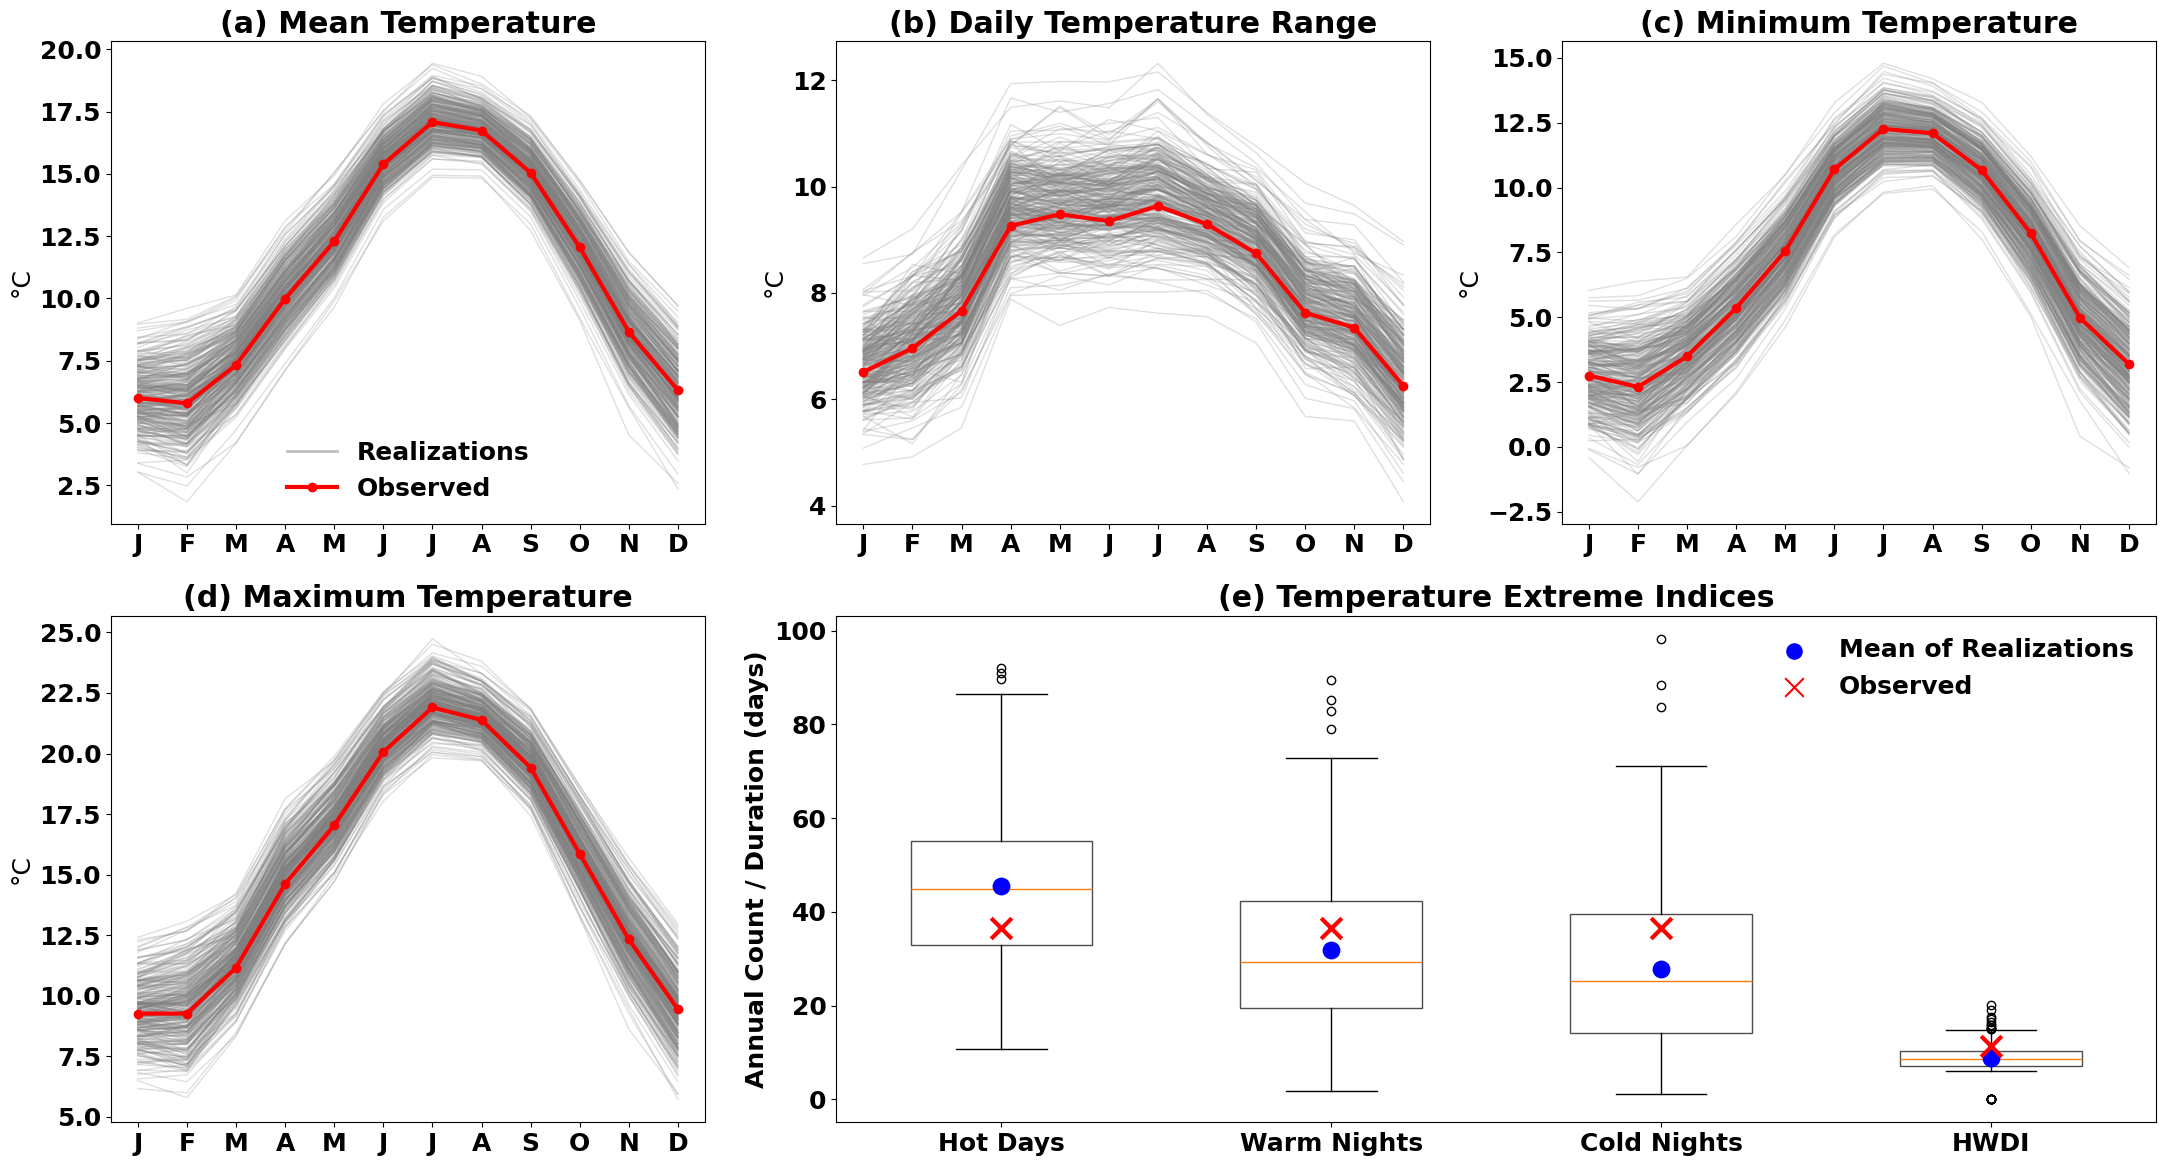

In [24]:
months = np.arange(1,13)
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

plt.rcParams.update({'font.size':18})
plt.rcParams['font.weight']='bold'
fig = plt.figure(figsize=(22,12))

gs = GridSpec(2,3,figure=fig,height_ratios=[1,1.05])

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,0])

# make extreme indices span 2 columns
ax5 = fig.add_subplot(gs[1,1:])
axs = [ax1,ax2,ax3,ax4]



temp_data = [
    (TEMP_AVG_filled, OBS_TEMP['mean'].values, "Mean Temperature", "°C"),
    (DTR_filled, OBS_DTR['mean'].values, "Daily Temperature Range", "°C"),
    (TEMP_MIN, OBS_TEMPMIN.values, "Minimum Temperature", "°C"),
    (TEMP_MAX, OBS_TEMPMAX.values, "Maximum Temperature", "°C")
]

letters = ['(a)','(b)','(c)','(d)','(e)']
real_handle = Line2D([0],[0],color='grey',alpha=0.5,lw=2,label='Realizations')
obs_handle = Line2D([0],[0],color='red',marker='o',lw=3,label='Observed')

for i,(ax,(realR,obs,title,unit)) in enumerate(zip(axs,temp_data)):
    realR = realR.copy()
    realR.index = pd.to_datetime(realR.index)
    monthly = realR.groupby(realR.index.month).mean()
    for col in monthly.columns:
        ax.plot(months,monthly[col],color='grey',alpha=0.25,linewidth=1)

    ax.plot(months,obs,'-o',color='red',linewidth=3)
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_title(f'{letters[i]} {title}',fontweight='bold')
    ax.set_ylabel(unit)

    if i == 0:
        ax.legend(handles=[real_handle,obs_handle],frameon=False)



DATA = [REAL_HOT,REAL_WARM,REAL_COLD,REAL_HWDI]
OBS = [OBS_MEAN_TMAX,OBS_MEAN_TMIN,OBS_MEAN_TMIN_COLD,OBS_HWDI]
LABELS = ['Hot Days', 'Warm Nights', 'Cold Nights','HWDI']
DATA = [np.array(x)[~np.isnan(x)] for x in DATA]

bp = ax5.boxplot(DATA,patch_artist=True,widths=0.55)
for box in bp['boxes']:
    box.set(facecolor='white',alpha=0.7)

for i,(vals,obs) in enumerate(zip(DATA,OBS),start=1):
    ax5.scatter(i,np.mean(vals),color='blue',s=140,zorder=10)
    ax5.scatter(i,obs,marker='x',s=220,linewidth=3,color='red',zorder=11)

ax5.set_xticklabels(LABELS,fontsize=18,fontweight='bold')
ax5.set_ylabel('Annual Count / Duration (days)',fontweight='bold')
ax5.set_title('(e) Temperature Extreme Indices',fontweight='bold')
ax5.scatter([],[],color='blue',s=120,label='Mean of Realizations')
ax5.scatter([],[],marker='x',color='red',s=180,label='Observed')
ax5.legend(frameon=False,loc='upper right')

# plt.suptitle('Cambridgeshire (2001 - 2020)',fontsize=22,fontweight='bold',y=0.98)
plt.tight_layout()
plt.savefig('/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/SuppF8.png',dpi=600,bbox_inches='tight')
plt.show()